In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from typing import List, Dict
import math
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## loading the data

In [61]:
# Loading train and test dataset
train_df = pd.read_csv('train.csv') 
test_df = pd.read_csv('test.csv')
print('Train file size is:', train_df.shape)
print('Test file size is:' ,test_df.shape)

Train file size is: (55462, 17)
Test file size is: (18000, 16)


In [62]:
# check the features type
train_df.dtypes

ID                       int64
worked_in_the_past      object
age_group               object
disability              object
is_dev                  object
education               object
sex                     object
mental_issues           object
years_of_experience    float64
A                      float64
B                      float64
C                       object
D                      float64
country                 object
prev_salary            float64
stack_experience        object
label                    int64
dtype: object

We can see that our data has 17 columns: 7 numeric and 10 objects.  55462 samples 

# visualization and statistics


In [63]:
train_df.drop(columns=['ID']).describe()

,years_of_experience,A,B,D,prev_salary,label
count,52898.000000,53327.000000,51927.000000,52843.000000,52798.000000,55462.000000
mean,14.214847,4.003959,9.079612,179.580295,67800.074662,0.536223
std,9.391586,6.392311,7.965858,1.094272,49583.999657,0.498691
min,0.000000,-21.637116,0.000000,175.077992,1.000000,0.000000
25%,7.000000,-0.362863,3.000000,178.843985,28800.000000,0.000000
50%,12.000000,3.606089,7.000000,179.584091,57660.000000,1.000000
75%,20.000000,7.852744,12.000000,180.323694,95979.000000,1.000000
max,50.000000,55.495063,50.000000,184.151007,224000.000000,1.000000


From the statistics of data, we can see for example that the average salary is 67800, the maximum year of experience is 50 years... 
this table helps us understand the data we are working with.

From the following results, we have approximately half the data with label '1' and a little less than half with label '0' , the data is balanced:

In [64]:
accepted= (train_df['label']==1).sum()
Unacceptable= (train_df['label']==0).sum()

print('the number of accepted applicants is:' ,accepted)
print('the number of Unacceptable applicants is:' ,Unacceptable)

percentage_of_acc= accepted *100/(train_df['label']).count()
print(percentage_of_acc,'%')

the number of accepted applicants is: 29740
the number of Unacceptable applicants is: 25722
53.62229995312106 %


Binary columns are: ['worked_in_the_past', 'age_group', 'disability', 'is_dev', 'mental_issues', 'label']


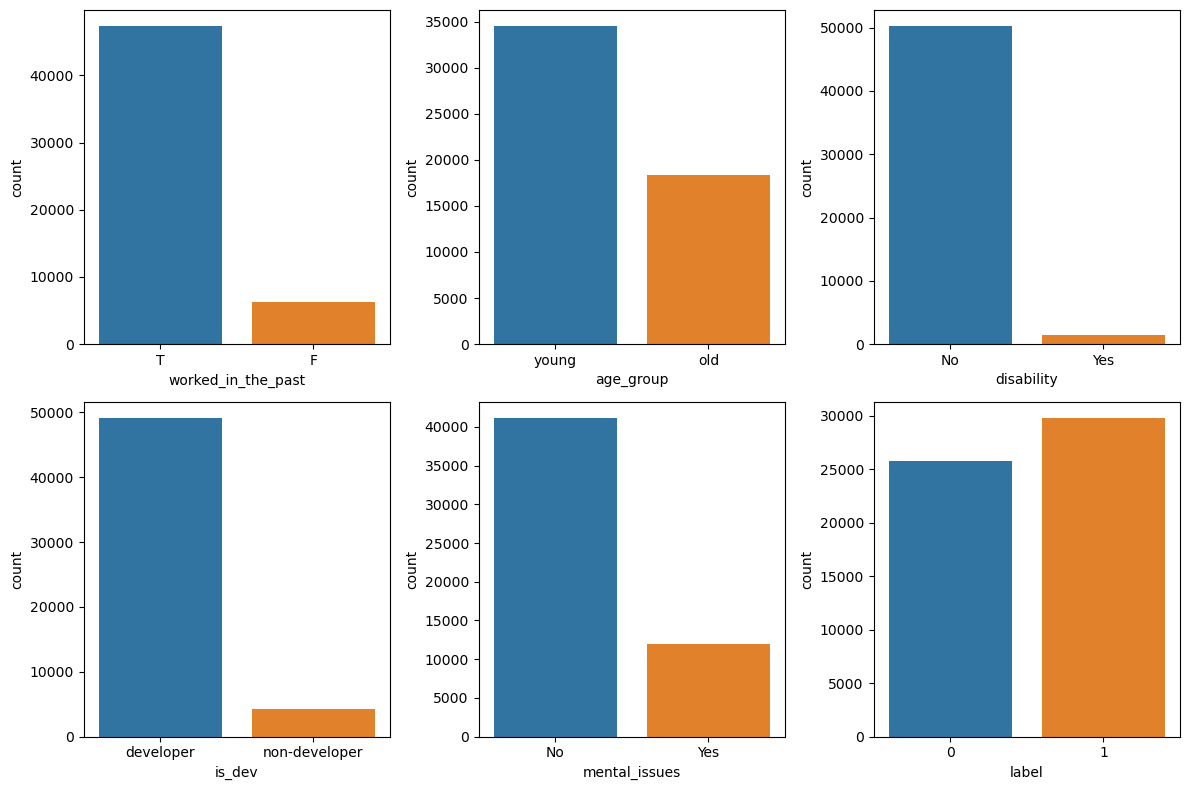

In [65]:
# visualize :

#get the columns from the num_dataframe that consider binary
binary_columns = [col for col in train_df.columns if train_df[col].nunique() == 2]
print(f'Binary columns are:', binary_columns)

#calculation of the number of rows and columns required
num_cols = len(binary_columns)
num_rows = math.ceil(num_cols / 3)  # 3 עמודות בכל שורה
plt.figure(figsize=(12, 4 * num_rows))

# create a graph for each biarZay column:
for i, col in enumerate(binary_columns, 1):
    plt.subplot(num_rows, 3, i)  # התאמת השורות והעמודות בהתאם למספר העמודות
    sns.countplot(x=col, data=train_df)
    plt.xlabel(col)

plt.tight_layout()  # התאמת ריווח בין הגרפים
plt.show()



Visualize the numeric columns:

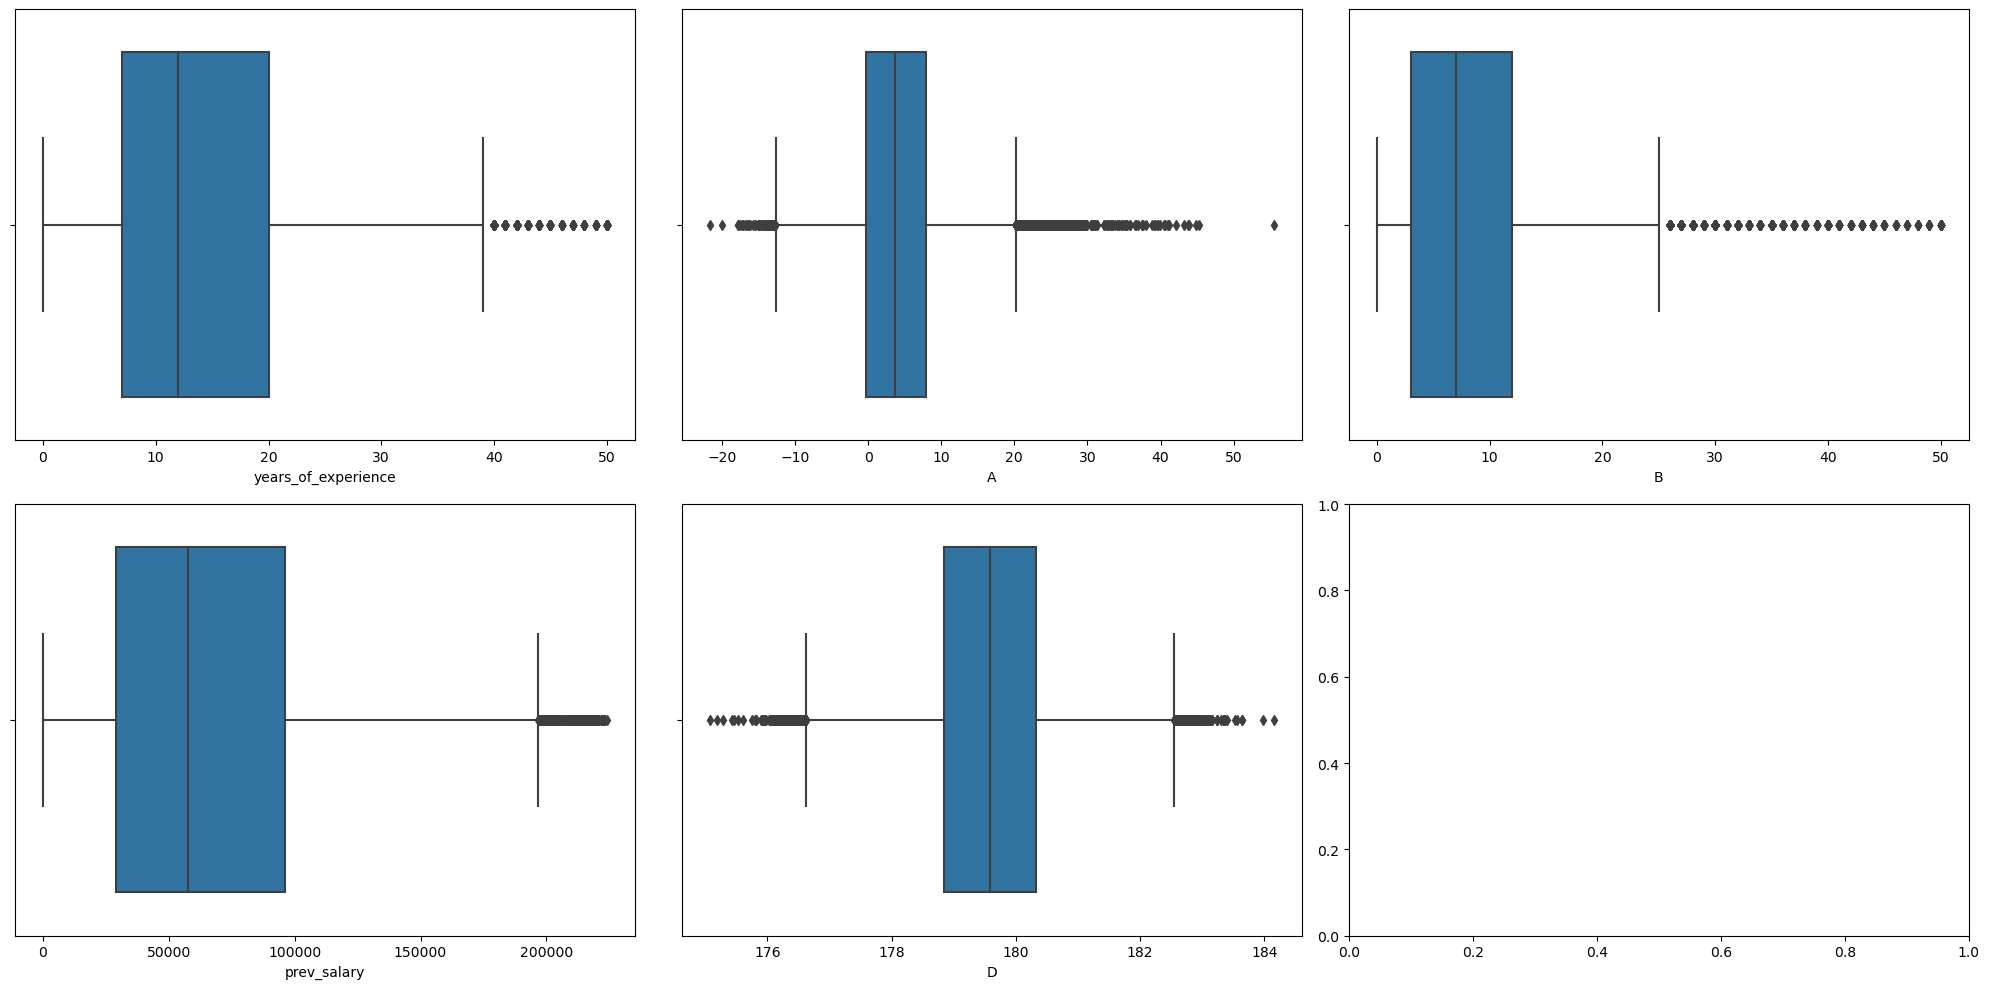

In [66]:
col = ['years_of_experience', 'A', 'B', 'prev_salary', 'D']
plo, axis = plt.subplots(nrows=2, ncols=3, figsize=(20,10))
axis = axis.flatten()
for i, j in enumerate(col):
    sns.boxplot(x=j, data=train_df, ax=axis[i])
plo.tight_layout()
plt.show()


from the boxplot we got a clear visual summry of the distribution of the data including the median, quartiles and outliers (the black dots ).
this helps identify skweness, symmetry and the presence of extreme values.
now let's look at those values and alayze the outliers

non binary columns are: ['years_of_experience', 'A', 'B', 'D', 'prev_salary']
number of non binary columns: 5


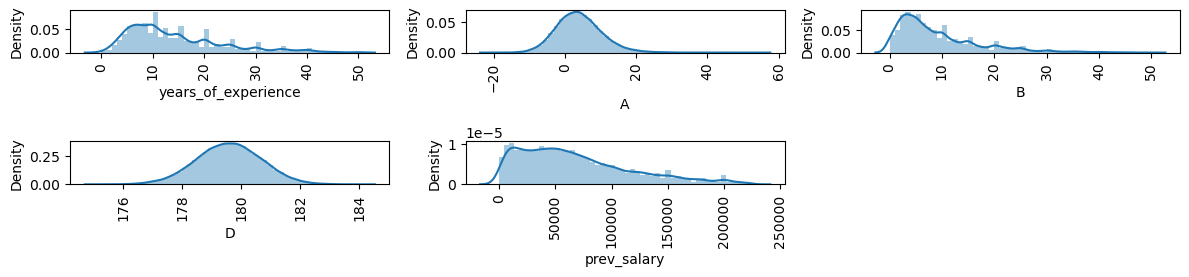

In [67]:
non_binary_columns=[
 'years_of_experience',
 'A',
 'B',
 'D',
 'prev_salary',]
print(f'non binary columns are:',non_binary_columns)
print(f'number of non binary columns:',len(non_binary_columns))
#in subplot of 5*3 we will plot the binary columns using seaborn the chart type is distplot
#make the graph wider and fit the labels in the x axis vertical
plt.figure(figsize=(12,6))
for i,col in enumerate(non_binary_columns,1):
    plt.subplot(5,3,i)
    sns.distplot(train_df[col])
    plt.xlabel(col)
    plt.tight_layout()  # התאמת ריווח בין הגרפים
    plt.xticks(rotation=90)

The graph visualize the distribution and variability of the the numeric features, which is useful for understanding the data and preparing it for further analysis.

Years of Experience: plot shows that most individuals have fewer years of experience, with a peak around 0-10 years, and then it gradually declines as years increase.

A and B:   show distributions with a peak around a certain value (possibly close to zero for A and around 5-10 for B). Both distributions have a right-skewed tail, indicating fewer instances as the values increase.

D: the distribution seems to be more symmetric and centered around a specific value, likely around 179-180.

Prev_salary: a distribution that is highly right-skewed, with most salaries clustered at the lower end and a long tail extending toward higher salaries.


#### outliers

remove outliers function 

In [68]:
def remove_outliers(df, column, lower_quantile=0.05, upper_quantile=0.95, threshold=1.5):
    Q1 = df[column].quantile(lower_quantile)
    Q3 = df[column].quantile(upper_quantile)
    IQR = Q3 - Q1

    # הגדרת הגבולות עבור נתונים חריגים
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    # סינון הנתונים החריגים
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df_cleaned

this function calculates the lower and upper boundaries for outlier detection using the interquartile range (IQR) method, where outliers are defined as values outside the range [Q1 - threshold * IQR, Q3 + threshold * IQR]. It then filters the df to retain only rows where the values in the specified column fall within these boundaries.
The threshold here is used to determine how far from the interquartile range (IQR) the boundaries for outliers should be set. the threshold is set to 1.5, which is a common choice in statistics. This means that any value in the specified column that is more than 1.5 times the IQR below the first quartile (Q1) or above the third quartile (Q3) is considered an outlier and will be removed from the dat. Adjusting the threshold value can make the outlier detection more or less strict.
We choce to handle outliers with this method although we didn't learn about it , since its a robust and widely accepted technique to identify and remove outliers. The IQR method focuses on the middle 50% of the data, between the first quartile (Q1) and third quartile (Q3), making it less sensitive to skewed distributions compared to methods that rely on the mean and standard deviation.

<Axes: xlabel='prev_salary'>

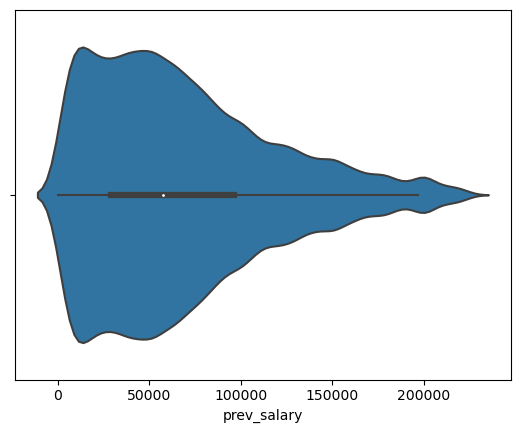

In [69]:
# 'prev_salary' column distribution before the cleaning of outliers
sns.violinplot(x='prev_salary', data=train_df)

<Axes: xlabel='prev_salary'>

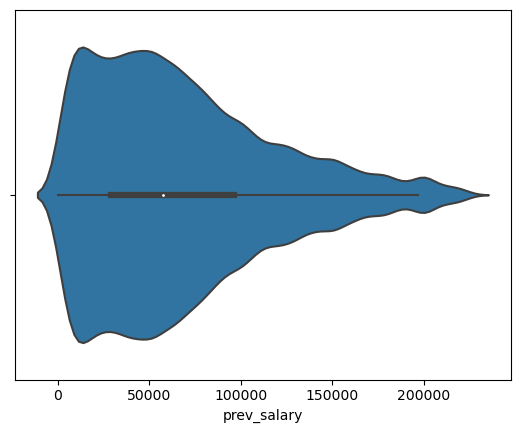

In [70]:
outliers_free_df = remove_outliers(train_df, 'prev_salary', lower_quantile=0.05, upper_quantile=0.95, threshold=1.5)

#visualizatoin of the outlier removal on 'prev_salary' column
sns.violinplot(x='prev_salary', data=outliers_free_df)

# It should be noted that with upper_quantile = 0.95 there is no such difference between before and after removing outliers. 
# this may indicate that prev_salary column contain few oultiers dots.
# It might be hard to distinguish between real values and outliers, we should be careful when removing data.

<Axes: xlabel='A'>

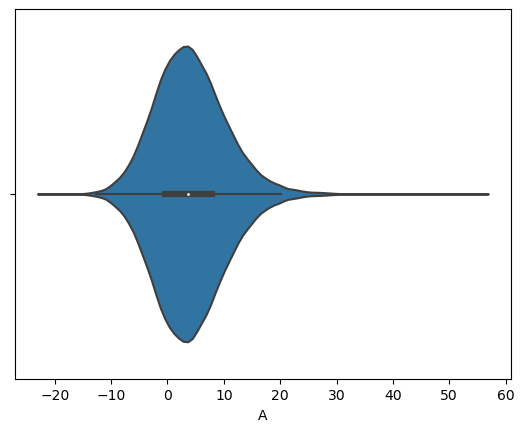

In [71]:
# 'A' column before cleaning outliers
sns.violinplot(x='A', data=train_df)


<Axes: xlabel='A'>

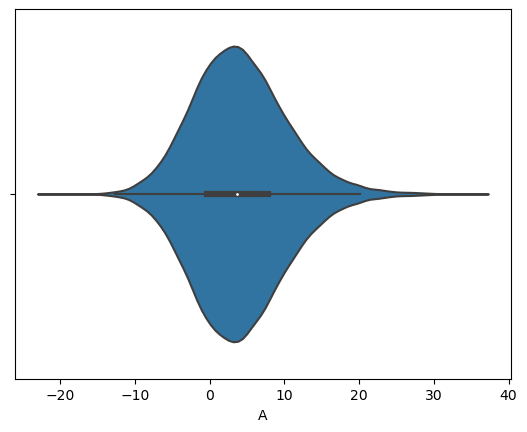

In [72]:
outliers_free_df = remove_outliers(train_df, 'A', lower_quantile=0.1, upper_quantile=0.9, threshold=1.5)

#visualizatoin of the outlier removal effect on 'A' column:
sns.violinplot(x='A', data=outliers_free_df)

# The distribution looks better after removing the outliers ( quantiles = [0.9 0.1] ) , in this case, it is most likely to contain many outliers, as can be also seen in the boxplot (many black dots)
# In this case the removing is justified, but still we should remove data with caution since we don't want to lose information .

<Axes: xlabel='years_of_experience'>

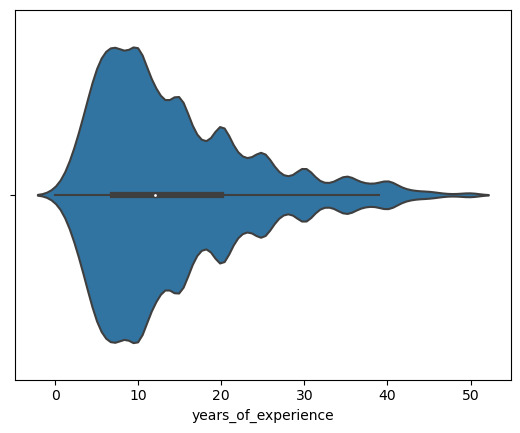

In [73]:
# years_of_experience before
sns.violinplot(x='years_of_experience', data=train_df)

<Axes: xlabel='years_of_experience'>

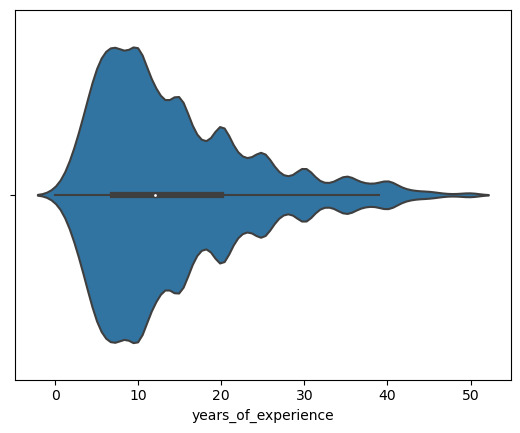

In [74]:
outliers_free_df = remove_outliers(train_df, 'years_of_experience', lower_quantile=0.15, upper_quantile=0.85, threshold=1.5)

#visualizatoin of the outlier removal effect on years_of_experience column
sns.violinplot(x='years_of_experience', data=outliers_free_df)

# when defining upper quantile to 0.9 and above, no observable changes are found, it may be that this feature contain few outliers, as can be also seen in the boxplot.

<Axes: xlabel='B'>

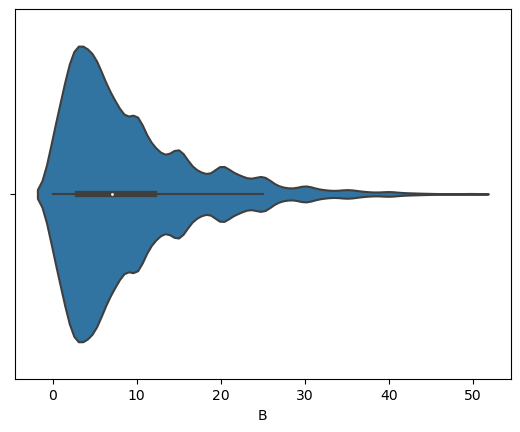

In [75]:
#'B' before removing outliers

sns.violinplot(x='B', data=train_df)

<Axes: xlabel='B'>

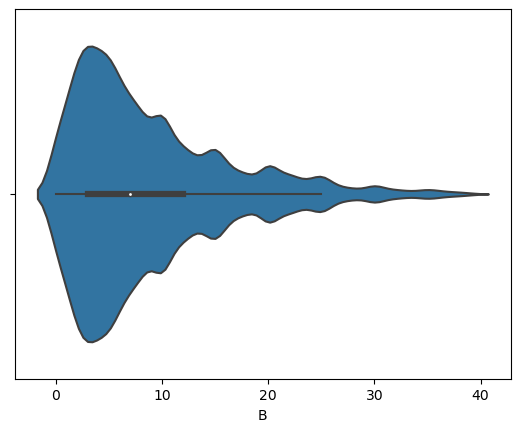

In [76]:
#'B' after removing outliers:
outliers_free_df = remove_outliers(train_df, 'B', lower_quantile=0.15, upper_quantile=0.85, threshold=1.5)

#visualizatoin of the outlier removal effect
sns.violinplot(x='B', data=outliers_free_df)

# with the chosen quantiles, the outliers where removed , but real data points may be also removed 

<Axes: xlabel='D'>

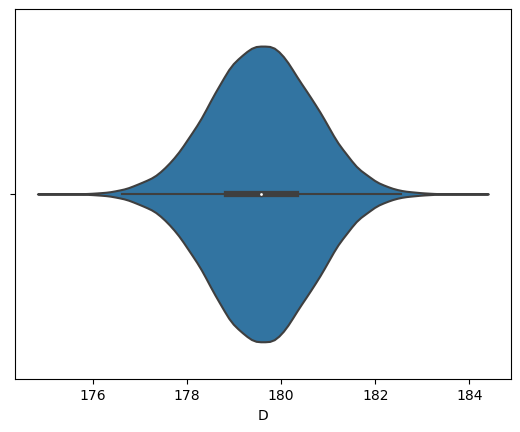

In [77]:
sns.violinplot(x='D', data=train_df)

<Axes: xlabel='D'>

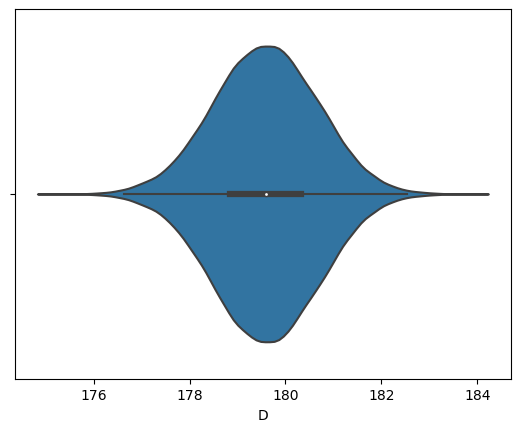

In [78]:
outliers_free_df = remove_outliers(train_df, 'D', lower_quantile=0.15, upper_quantile=0.85, threshold=1.5)

#visualizatoin of the outlier removal effect on 'D' column
sns.violinplot(x='D', data=outliers_free_df)

# no sifference is observable.

Interpreting mysterious given features:

<Axes: xlabel='label', ylabel='D'>

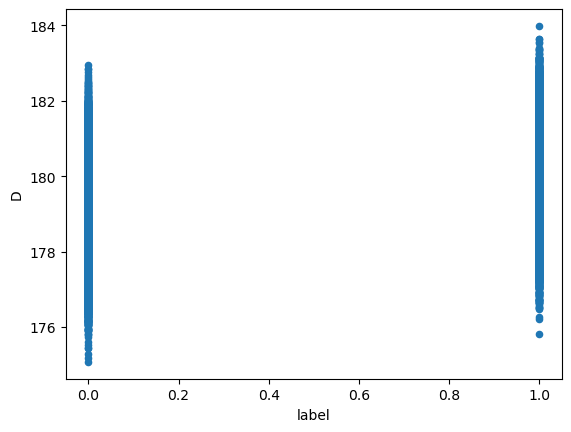

In [79]:
#understanding the 'D' feature by its relationship with the labels:
outliers_free_df.plot(x='label',y='D',kind='scatter')

from the first look of the feature 'D' and the data we can interfered that this feature is height, and if its true we can see that taller people tend to get hired more  

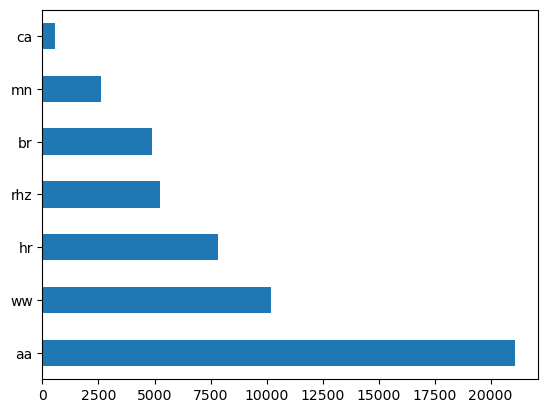

In [80]:
#feature C:
train_df['C'].value_counts().head(10).plot.barh()
plt.show()

we dont understand what this feature is or what information it gives, but in our data there more than 20,000 samples with the value 'aa'

Closer look to each feature:

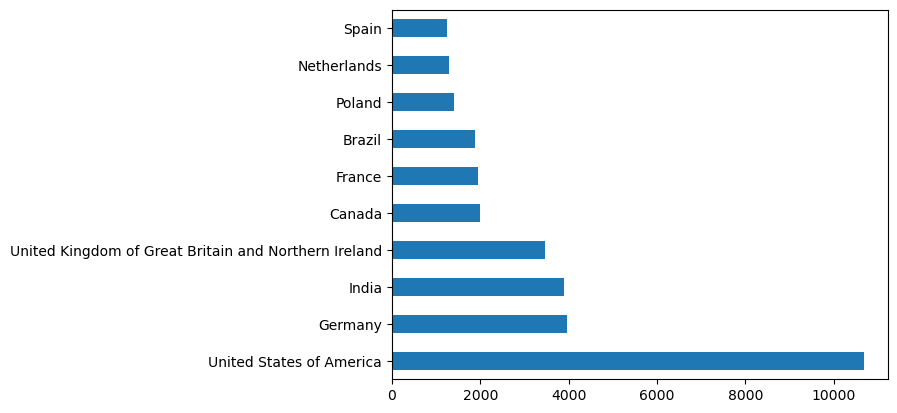

In [81]:
train_df['country'].value_counts().head(10).plot.barh()
plt.show()

from looking at the first 10 countries; we can see that most of our applicants are from the united states of america

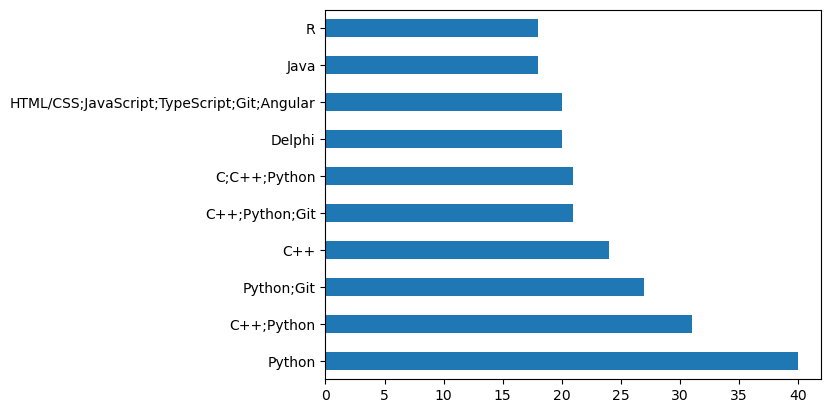

In [82]:
train_df['stack_experience'].value_counts().head(10).plot.barh()
plt.show()

This bar plot shows the counts of different combinations of stack experiences and program languages.
From here, we undersatnd that an informative way to represent this feature in the data is to split is into categories of languages, ore to represent each language in a single one-hot-encoding vector. 
* One-hot encoding is a technique used to represent categorical features as binary vectors, where each category is transformed into a vector with all zeros except for a single one at the index corresponding to that category. This method allows machine learning models to interpret categorical data by converting it into a numerical format without assuming any ordinal relationship between the categories.

## Feature transformations

Since we have 170 countries, one-hot encoding for each single country can result in a high-dimensional feature space, which might be computationally expensive and inefficient. Alternativly we group countries in the same continents together and apply one-hot encoding to these grouped categories, this reduce the overall dimensionality while still capturing the essential information.


In [83]:
def categorize_and_encode_countries(df):
    # Step 1: define continents and their countries
    continents = {
        'Asia':
    ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Bhutan', 'Cambodia', 'China', 'India', 'Indonesia', 
     'Iran, Islamic Republic of...', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan',
     "Lao People's Democratic Republic", 'Lebanon', 'Maldives', 'Nepal', 'Oman', 'Pakistan', 'Palestine', 'Philippines',
     'Republic of Korea', 'Saudi Arabia', 'Singapore', 'Sri Lanka', 'Syrian Arab Republic', 'Taiwan', 'Tajikistan', 'Thailand',
     'Turkmenistan', 'United Arab Emirates', 'Viet Nam', 'Yemen'],
        'Europe':
    ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 
     'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 
     'Isle of Man', 'Italy', 'Kosovo', 'Latvia', 'Luxembourg', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 'Norway',
     'Poland', 'Portugal', 'Republic of Moldova', 'Romania', 'Russian Federation', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 
     'Sweden', 'Switzerland',
     'The former Yugoslav Republic of Macedonia', 'Turkey', 'Ukraine', 'United Kingdom of Great Britain and Northern Ireland'],
        'Africa':
    ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Cape Verde', 'Congo, Republic of the...', 
     "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Egypt', 'Ethiopia', 'Gambia', 'Ghana', 'Guinea', 
     'Libyan Arab Jamahiriya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Mozambique', 'Namibia', 
     'Niger', 'Nigeria', 'Rwanda', 'Senegal', 'Seychelles', 'Somalia', 'South Africa', 'Sudan', 'Swaziland', 'Togo',
     'Tunisia', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe'],
        'North America':
    ['Canada', 'Costa Rica', 'Dominican Republic', 'El Salvador', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 
     'Nicaragua', 'Panama', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago', 
     'United States of America'],
        'South America':
    ['Argentina', 'Belize', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Nicaragua', 'Paraguay',
     'Peru', 'Suriname', 'Uruguay', 'Venezuela, Bolivarian Republic of...'],
        'Oceania':
    ['Australia', 'Fiji', 'New Zealand', 'Timor-Leste']
    }
    # Step 2: assign numeric labels to each continent
    continent_labels = {
        'Africa': 0,
        'Asia': 1,
        'Europe': 2,
        'North America': 3,
        'Oceania': 4,
        'South America': 5
    }

    # Step 3: map each country to its numeric label
    country_to_label = {}
    for continent, countries in continents.items():
        for country in countries:
            country_to_label[country] = continent_labels[continent]
    # Step 4: add encoded labels to the dataset
    df['country'] = df['country'].map(country_to_label)

    # handle countries not found in the dictionary
    df['country'].fillna(0, inplace=True)

    return df


train_df_categorized = categorize_and_encode_countries(train_df)


## categorizing the column stack_experience into categories 

Same as countries catergorizing, but here, the categories are:

System/Low-Level Languages: {Assembly, C, C++, Rust}

General-Purpose Languages: {
Python,Ruby,Swift,Kotlin,Java,Dart,F#
Elixir,Go,PHP.Groovy,TypeScript,Objective-C,R,MATLAB,Delphi,Scala
Perl,Julia,Lua,Solidity,Haskell,OCaml,LISP,APL, COBOL}

Scripting/Web Languages: {
Bash/Shell
JavaScript
HTML/CSS
PowerShell}

Database Query Languages: {SQL}

Legacy/Enterprise Languages:{Fortran, VBA}

Web Development Frameworks:{
Django,Flask,Spring,Ruby on Rails,Symfony,
Laravel,ASP.NET,ASP.NET Core,Express,FastAPI,Next.js,Gatsby,Phoenix
Blazor,Angular.js,Angular,React.js,Vue.js,jQuery}


Game Development Engines:{
Unity 3D
Unreal Engine }


Machine Learning/Data Science: {SAS}

Cloud Providers: {
Microsoft Azure,Google Cloud Platform
AWS,IBM Cloud or Watson
DigitalOcean,Oracle Cloud Infrastructure
Linode }


Containerization/Orchestration:{
Docker
Kubernetes
OpenStack}


DevOps Tools: {
Git
VMware
Chef
Puppet
Ansible
Terraform
Pulumi}


CI/CD and Package Management: {
npm
Yarn
Homebrew}


SQL Databases:{
MySQL
PostgreSQL
SQLite
Microsoft SQL Server
Oracle
MariaDB}

NoSQL Databases: {
MongoDB
Cassandra
Couchbase
Redis
DynamoDB
Elasticsearch
Firebase Realtime Database
Cloud Firestore
CouchDB
IBM DB2}


Additional Categories: {

Xamarin
Node.js
Deno
Unreal Engine
Managed Hosting
Heroku
Drupal}

In [84]:
def categorize_and_encode_techs(df_given):
    df = df_given.copy()
    technologies = {
        'programming_languages': [ #category 1
            'Assembly', 'C', 'C++', 'Rust',
            'Python', 'Ruby', 'Swift', 'Kotlin', 'Java', 'Dart', 'F#', 'Elixir', 'Go',
            'PHP', 'Groovy', 'TypeScript', 'Objective-C', 'R', 'MATLAB', 'Delphi', 'Scala', 'Perl', 'Julia', 'Lua',
            'Solidity', 'Haskell', 'OCaml', 'LISP', 'APL', 'COBOL',
            'Bash/Shell', 'JavaScript', 'HTML/CSS', 'PowerShell',
            'SQL',
            'Fortran', 'VBA'
        ],
        'frameworks_and_libraries': [ #category 2
            'Django', 'Flask', 'Spring',
            'Ruby on Rails', 'Symfony', 'Laravel', 'ASP.NET', 'ASP.NET Core', 'Express', 'FastAPI', 'Next.js', 'Gatsby', 'Phoenix', 'Blazor',
            'Angular.js', 'Angular', 'React.js', 'Vue.js', 'jQuery',
            'Unity 3D', 'Unreal Engine',
            'SAS'
        ],
        'Cloud Providers': [ #category 3
            'Microsoft Azure', 'Google Cloud Platform', 'AWS', 'IBM Cloud or Watson', 'DigitalOcean', 'Oracle Cloud Infrastructure',
            'Linode'
        ],
        'Containerization/Orchestration': [ #category 4
            'Docker', 'Kubernetes', 'OpenStack'
        ],
        'devops_and_infrastructure': [ #category 5
            'Git', 'VMware', 'Chef', 'Puppet', 'Ansible', 'Terraform', 'Pulumi',
            'npm', 'Yarn', 'Homebrew'
        ],
        'SQL Databases': [ #category 6
            'MySQL', 'PostgreSQL', 'SQLite', 'Microsoft SQL Server', 'Oracle', 'MariaDB'
        ],
        'NoSQL Databases': [ #category 7
            'MongoDB', 'Cassandra', 'Couchbase', 'Redis', 'DynamoDB', 'Elasticsearch', 'Firebase Realtime Database', 'Cloud Firestore', 'CouchDB',
            'IBM DB2'
        ],
        'other_technologies': [ #category 8
            'Xamarin', 'Node.js', 'Deno', 'Unreal Engine', 'Managed Hosting', 'Heroku', 'Drupal'
        ]
    }

    category_type = {
        'programming_languages': 1,
        'frameworks_and_libraries': 2,
        'Cloud Providers': 3,
        'Containerization/Orchestration': 4,
        'devops_and_infrastructure': 5,
        'SQL Databases': 6,
        'NoSQL Databases': 7,
        'other_technologies': 8
    }

    # Splitting the values ​​in the column into a list, with handling in cases where the value is not a string
    df['stack_experience'] = df['stack_experience'].apply(lambda x: x.split(';') if isinstance(x, str) else [])

    # convert to a list of categories
    def map_to_category(tech_list):
        return [tech_to_label.get(tech.strip(), 0) for tech in tech_list if isinstance(tech, str)]

    # A dictionary maps each technology to its category
    tech_to_label = {tech: category_type[category] for category, techs in technologies.items() for tech in techs}

    # conversion of each list of technologies into a list of categories
    df['stack_experience'] = df['stack_experience'].apply(map_to_category)

    # Creating binary columns for each category
    for category in category_type.values():
        df[f'Category_{category}'] = 0

    # updating the binary columns based on the categories present in each row
    for i, row in df.iterrows():
        for category in row['stack_experience']:
            if category != 0:
                df.at[i, f'Category_{category}'] = 1

    # removing the original column
    df = df.drop(columns=['stack_experience'])

    return df

In [85]:
train_df_categorized = categorize_and_encode_techs(train_df_categorized)
train_df_categorized

,ID,worked_in_the_past,age_group,disability,is_dev,education,sex,mental_issues,years_of_experience,A,...,prev_salary,label,Category_1,Category_2,Category_3,Category_4,Category_5,Category_6,Category_7,Category_8
0,65168,T,young,No,developer,NaN,Male,No,13.0,-1.093080,...,67104.0,1,1,1,1,1,1,0,0,1
1,38314,T,young,No,non-developer,other,Male,Yes,7.0,5.444533,...,101000.0,0,1,0,1,1,1,0,0,0
2,5209,T,old,No,developer,other,Male,Yes,25.0,1.727255,...,70000.0,0,1,1,0,0,1,1,0,0
3,54165,T,young,NaN,developer,other,Male,No,10.0,17.804302,...,40956.0,0,1,1,0,1,0,1,1,1
4,42213,T,young,No,developer,BA/BSc,Male,No,12.0,-8.679091,...,101509.0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55457,64649,T,young,No,developer,BA/BSc,Male,No,7.0,6.868416,...,80000.0,1,0,0,0,0,0,0,0,0
55458,57832,T,NaN,NaN,developer,MA/MSc,Male,No,22.0,2.030205,...,149568.0,1,1,1,1,1,1,1,1,1
55459,47358,T,old,No,developer,BA/BSc,Male,No,35.0,1.473015,...,NaN,1,1,1,1,1,1,1,1,1
55460,36055,T,young,NaN,developer,BA/BSc,Male,No,6.0,-0.883305,...,105000.0,1,1,1,1,0,1,1,0,1


## Dealing with categorical features
We chose to use the pd.Categorical function in pandas, to transform a categorical column into a categorical data type (convet categoru to code). This gives a unique integer code to each category, starting from 0. For example, education 'BA/BSc' is mapped to 0, 'High school' is mapped to 1
and so on (see the example).  Missing values are represented by -1, which is later replaced with NaN to preserve them for further processing.

In [86]:
def convert_categorical_to_numeric(df_given):
    df = df_given.copy()
    #  hold category-to-code mappings
    category_mappings = {}
    exclude_columns = ['stack_experience','country']
    # Idientify categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    categorical_columns = [col for col in categorical_columns if col not in exclude_columns]

    # convert each categorical column to numeric
    for column in categorical_columns:
        df[column] = pd.Categorical(df[column])
        
        # get category-to-code mapping
        mapping = dict(enumerate(df[column].cat.categories))
        category_mappings[column] = mapping
        
        #keep NaN values
        df[column] = df[column].cat.codes.replace(-1, np.nan)
    
    return df, category_mappings


numeric_df,category_mappings = convert_categorical_to_numeric(train_df_categorized)

In [87]:
category_mappings

{'worked_in_the_past': {0: 'F', 1: 'T'},
 'age_group': {0: 'old', 1: 'young'},
 'disability': {0: 'No', 1: 'Yes'},
 'is_dev': {0: 'developer', 1: 'non-developer'},
 'education': {0: 'BA/BSc',
  1: 'High school',
  2: 'MA/MSc',
  3: 'Phd',
  4: 'other'},
 'sex': {0: 'Female', 1: 'Male', 2: 'Other'},
 'mental_issues': {0: 'No', 1: 'Yes'},
 'C': {0: 'aa', 1: 'br', 2: 'ca', 3: 'hr', 4: 'mn', 5: 'rhz', 6: 'ww'}}

## Correlation Matrix

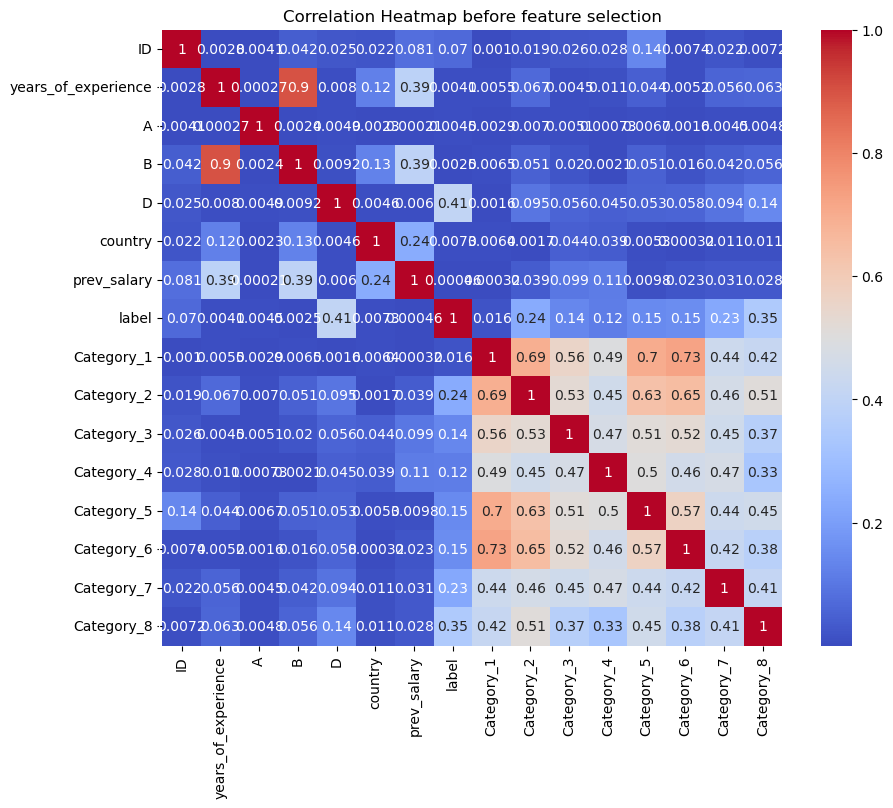

In [88]:
# check the correlation between features:
corr_matrix = abs(train_df_categorized.corr())

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,              
            cmap='coolwarm',         
            xticklabels=corr_matrix.columns,
            yticklabels=corr_matrix.columns)

plt.title('Correlation Heatmap before feature selection')
plt.show()


The figure displays the correlation coefficients between features in a dataset. Each cell in the matrix shows the strength and direction of the relationship between two variables. We can see the feature B is correlated with years of experience. and also there are some features that are correlated with value higher than 0.7. This information  can be useful for feature selection, reducing multicollinearity, and improving model performance by removing redundant feature.

## Handling the missing values 

First, let's examinate the counts of missing values:

In [89]:
rows_with_nan=train_df.isnull().any(axis=1).sum()
print('percentage of samples with NaN values in train file : ' ,rows_with_nan/train_df.shape[0])

percentage of samples with NaN values in train file :  0.6136814395441924


the precentage of the missing values is very large,
our first impression is that we cannot remove all the rows because we will lose a lot of our data.

In [90]:
nan_count = train_df.isna().sum()
print (nan_count)

ID                         0
worked_in_the_past      1765
age_group               2540
disability              3681
is_dev                  2090
education               3016
sex                     3228
mental_issues           2415
years_of_experience     2564
A                       2135
B                       3535
C                       3002
D                       2619
country                    0
prev_salary             2664
stack_experience       14042
label                      0
dtype: int64


In [91]:
# look at the percentages
cols_with_nan = 100* (nan_count / len(train_df))
cols_with_nan

ID                      0.000000
worked_in_the_past      3.182359
age_group               4.579712
disability              6.636977
is_dev                  3.768346
education               5.437958
sex                     5.820201
mental_issues           4.354333
years_of_experience     4.622985
A                       3.849483
B                       6.373733
C                       5.412715
D                       4.722152
country                 0.000000
prev_salary             4.803289
stack_experience       25.318236
label                   0.000000
dtype: float64

The number of Nan values in each feature is relatively small so we think of filling them each according to their type.

1 - fill with 0: 

* We notice that the feature 'stack_experience' has a lot of missing values (25.3%) but considering the meaning of the feature if there is a missing value so there is no experience so we will fill it with a new variable which we will call noEXP.
and when converting to numeric features, this could be 0 indicating that the person have no experience.

* 'worked_in_the_past' feature indicates whether the candidate have an experience. We suggest that the missing value indicates a 0 - didn't work in the past

* 'disability': we chose to fill the missing values with 0, because usually there are no disability as long as it is not noted elsewise.

* is_dev : fill with 0


* 'mental_issues': we suggest that the missing values indicate there is no mental issues so we fill them with 0 

-------
2- fill with 'other' category: 

* for 'country' column, fill with additional category of 'other' , when converting to binary , it woulg have a special label.
* 'sex' - see notes below
* 'education'

-------
3- special treatment:

* The missing values in 'age_group' can be filled considering the years of experience: : if the years of experience is more than 17 (chosen Threshould = 17) years, we define it as old. Since old candidates is more likely to start gain experiens at the good case at the age of 18. then, 18+17=35 which is the threshold age above the candidate considered old.

* fill the missing values in the 'years_of_experience' , A' & 'B' & 'D' column by sampling from the distribution of the rest of the values in the feature.

* fill the missing values in the 'prev_salary' column by the mean of the salaries of people who have experience within a certain range (e.g., within plus or minus 2 years of experience).
By using the mean salary of candidates with similar experience levels, the filled values are based on relevant and related data. This based on the assumption that salary is correlated with experience.

------
4- Delete the rows:
Delete all the rows contain the Null value of 'C' column. This is a challenging part because we didn't know the meaning of the feature , so it is hard to handle missing values and minimizing the noise added to the data.

Note about 'sex' column: : We tried to infer sometheing about the 'sex' from the salary, but we found that the mean salary for male and female is nearly close so we cannot distinguish between the genders according to salary. So, we decided to fill the missing value in the gender as others.

In [92]:
print(train_df[train_df['sex'] == 'Male']['prev_salary'].mean())
train_df[train_df['sex'] == 'Female']['prev_salary'].mean()
#כישלון
#---> fill with 'other'

67768.18859639682


64400.880476393024

The code, given the df returns the cleaned df without any nan values:

In [93]:
def handling_missing_values_new(df):
    # רשימת העמודות שצריך למלא בהן ערכים חסרים
    columns_to_fill = ['Category_1', 'Category_2', 'Category_3', 'Category_4', 'Category_5', 'Category_6', 'Category_7', 'Category_8', 'worked_in_the_past', 'disability', 'mental_issues']

    # בדיקה אם העמודות קיימות, ואם לא, הוספת עמודות עם ערכים של '0'
    for col in columns_to_fill:
        if col not in df.columns:
            df[col] = '0'  # יצירת עמודה חדשה עם ערכים של '0'
        else:
            df[col] = df[col].fillna('0')  # מילוי NaN ב-'0' בעמודות קיימות

    # מילוי ערכים חסרים בעמודה 'is_dev'
    if 'is_dev' in df.columns:
        df['is_dev'] = df['is_dev'].fillna('0')

    # מילוי ערכים חסרים בעמודות 'sex' ו-'education'
    for column in ['sex', 'education']:
        if column in df.columns:
            max_value = df[column].max()  # הערך הגדול ביותר בקטגוריה (למשל 'others')
            df[column].fillna(max_value, inplace=True)

    # מילוי ערכים חסרים בעמודות 'years_of_experience', 'A', 'B', 'D'
    def fill_with_normal_dist(value, mean, std): # פונקציה למילוי ערכים חסרים עם דגימות מהתפלגות נורמלית
        if pd.isna(value):
            return np.random.normal(mean, std)
        else:
            return value

    for col in ['years_of_experience', 'A', 'B', 'D']:
        if col in df.columns:
            mean_value = df[col].mean()
            std_dev = df[col].std()
            df[col] = df[col].apply(fill_with_normal_dist, args=(mean_value, std_dev))

    # טיפול בעמודה 'age_group'
    if 'age_group' in df.columns and 'years_of_experience' in df.columns:
        df['age_group'] = df.apply(lambda row: 0 if pd.isna(row['age_group']) and row['years_of_experience'] > 17 else row['age_group'], axis=1)
        df['age_group'].fillna(1, inplace=True)  # מילוי ערכים חסרים שנותרו עם 'young'

    # מילוי ערכים חסרים בעמודה 'prev_salary'
    if 'prev_salary' in df.columns and 'years_of_experience' in df.columns:
        def mean_salary_within_range(experience, df, range_size=1):
            lower_bound = experience - range_size
            upper_bound = experience + range_size
            relevant_salaries = df[(df['years_of_experience'] >= lower_bound) &
                                   (df['years_of_experience'] <= upper_bound) &
                                   (~df['prev_salary'].isna())]['prev_salary']
            return relevant_salaries.mean() if not relevant_salaries.empty else np.nan

        df['prev_salary'] = df.apply(
            lambda row: mean_salary_within_range(row['years_of_experience'], df) if pd.isna(row['prev_salary']) else row['prev_salary'],
            axis=1
        )

    # הסרת שורות שבהן יש ערכים חסרים בעמודה 'C'
    if 'C' in df.columns:
        df = df[df['C'].notna()]

    return df


In [94]:

# check if the function did the job:
#train_df_cleaned = handling_missing_values_new(train_df)
#train_df_cleaned.isna().sum() # verified :)


## Normalize the data

In [95]:
def normalize_data(df, columns_to_normalize):
    # calculate the median and IQR for normalization
    median = df[columns_to_normalize].median()
    Q1 = df[columns_to_normalize].quantile(0.05)
    Q3 = df[columns_to_normalize].quantile(0.95)
    IQR = Q3 - Q1

    # Normalize using median and IQR
    df[columns_to_normalize] = (df[columns_to_normalize] - median) / IQR

    return df, median, IQR

Normalization helps in creating a balanced and efficient learning process, leading to more reliable and accurate models. Each value in the specified columns is normalized like this : (x−median)/IQR. 
This normalization method we did reduces the impact of outliers by scaling the data based on the median and interquartile range (IQR), rather than the mean and standard deviation, which are more sensitive to extreme values. By using the 5th and 95th percentiles to calculate the IQR, it further minimizes the influence of outliers.
We did this approach and give up on removing the outliers separtely. 

## Process train data

In [96]:
train_df_numeric,category_mappings = convert_categorical_to_numeric(train_df)
print('category mapping:',category_mappings)
train_df_cleaned = handling_missing_values_new(train_df_numeric)
train_df_cleaned = categorize_and_encode_countries(train_df_cleaned)
train_df_cleaned = categorize_and_encode_techs(train_df_cleaned)
# clean the ID column since we don't think it contribute to the prediction
train_df_cleaned = train_df_cleaned.drop('ID', axis=1)
train_df_norm,median_train,IQR_train = normalize_data(train_df_cleaned, ['years_of_experience','A','D','prev_salary']) 
train_df_norm

category mapping: {'worked_in_the_past': {0: 'F', 1: 'T'}, 'age_group': {0: 'old', 1: 'young'}, 'disability': {0: 'No', 1: 'Yes'}, 'is_dev': {0: 'developer', 1: 'non-developer'}, 'education': {0: 'BA/BSc', 1: 'High school', 2: 'MA/MSc', 3: 'Phd', 4: 'other'}, 'sex': {0: 'Female', 1: 'Male', 2: 'Other'}, 'mental_issues': {0: 'No', 1: 'Yes'}, 'C': {0: 'aa', 1: 'br', 2: 'ca', 3: 'hr', 4: 'mn', 5: 'rhz', 6: 'ww'}}


,worked_in_the_past,age_group,disability,is_dev,education,sex,mental_issues,years_of_experience,A,B,...,prev_salary,label,Category_1,Category_2,Category_3,Category_4,Category_5,Category_6,Category_7,Category_8
0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,0.03125,-0.228548,1.0,...,0.052952,1,1,1,1,1,1,0,0,1
1,1.0,1.0,0.0,1.0,4.0,1.0,1.0,-0.15625,0.088332,7.0,...,0.265237,0,1,0,1,1,1,0,0,0
2,1.0,0.0,0.0,0.0,4.0,1.0,1.0,0.40625,-0.091845,15.0,...,0.071089,0,1,1,0,0,1,1,0,0
3,1.0,1.0,0,0.0,4.0,1.0,0.0,-0.06250,0.687415,7.0,...,-0.110808,0,1,1,0,1,0,1,1,1
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.00000,-0.596245,4.0,...,0.268425,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55457,1.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.15625,0.157349,2.0,...,0.133718,1,0,0,0,0,0,0,0,0
55458,1.0,0.0,0,0.0,2.0,1.0,0.0,0.31250,-0.077161,20.0,...,0.569411,1,1,1,1,1,1,1,1,1
55459,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.71875,-0.104169,35.0,...,0.257030,1,1,1,1,1,1,1,1,1
55460,1.0,1.0,0,0.0,0.0,1.0,0.0,-0.18750,-0.218380,3.0,...,0.290289,1,1,1,1,0,1,1,0,1


Examine the distibution of the data after normalization

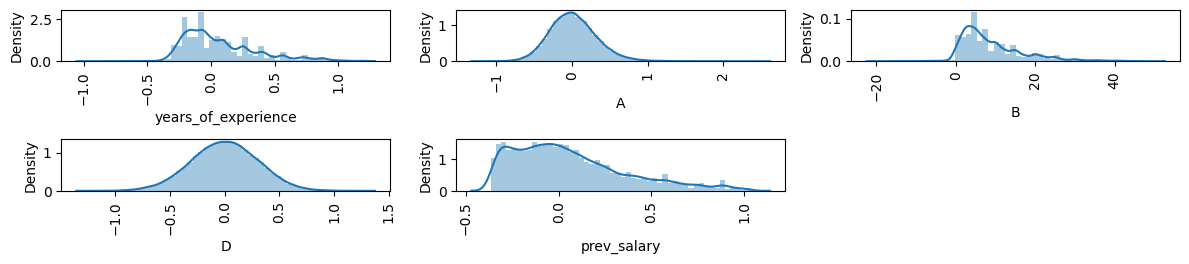

In [97]:
#get the data that is not binary

plt.figure(figsize=(12,6))
for i,col in enumerate(non_binary_columns,1):
    plt.subplot(5,3,i)
    sns.distplot(train_df_norm[col])
    plt.xlabel(col)
    plt.tight_layout()  
    plt.xticks(rotation=90)

This figure shows the density plots of the same numeric variables after normalization using IQR.

Years of Experience: The plot has been centered around the median, and the range of values is compressed, with most data falling between -1 and 1, indicating reduced influence from outliers.

A and B: Both distributions have been similarly centered and scaled. Although B still shows a right-skewed tail, the range is more controlled, indicating less influence from extreme values.

D: This distribution remains symmetric and centered around zero after normalization, showing effective scaling.

Prev_salary: The distribution has been compressed, reducing the impact of high salary outliers, making the data more uniformly distributed around the median.


## Feature Selection 

High dimensionality in data can lead to several challenges, including the curse of dimensionality, overfitting, increased computational complexity, and difficulties in visualization and interpretation. To address these issues, techniques such as feature selection, dimensionality reduction (e.g., PCA, LDA) can be employed to reduce the number of variables while retaining essential information, thereby improving model performance, reducing overfitting, and enhancing computational efficiency. Monitoring model performance, feature importance, and cross-validation scores can help recognize when dimensionality is too high. However, care must be taken to avoid losing valuable information during dimensionality reduction, as it can simplify models and improve generalization but also risks discarding important data.

 We chose the feature selection Filter method that we learned to reduce irrelevant variables while retaining essential information for better model performance.

Explanation of the Feature Selection Technique :
The function provided uses mutual information (MI) to select features that are most informative with respect to the labels. Here's a simplified breakdown:

Mutual Information Calculation:

For each feature in the dataset, the mutual information between the feature and the labels is calculated. This measures how much information the feature provides about the labels.
Feature Selection:

The feature with the highest mutual information score is selected first.
Iteratively, the function selects additional features. In each iteration, it adds the feature that, when combined with already selected features, maximizes the mutual information with the labels.
Return Selected Features:

The function returns the selected features and their indices.


In [98]:
from sklearn.feature_selection import mutual_info_classif

def select_features(x, Y_train, num_features_to_select=10):
    if not np.issubdtype(x.dtype, np.number):
        raise TypeError("x should contain numeric values only.")

    
    # calculate the mutual information
    mi_scores = mutual_info_classif(x, Y_train)
    
    # find the first best feature
    first_feature = np.argmax(mi_scores)
    selected_features = [first_feature]
    selected_indices = [first_feature]
    remaining_features = set(range(x.shape[1])) - set(selected_features)
    
    # בחירה איטרטיבית של תכונות כדי למקסם את המידע ההדדי המשולב
    for k in range(1, num_features_to_select):
        best_combined_mi = -np.inf
        best_feature = -1
        
        for i in remaining_features:
            combined_features = selected_features + [i]
            combined_data = x[:, combined_features]
            combined_mi = mutual_info_classif(combined_data, Y_train).sum()
            
            if combined_mi > best_combined_mi:
                best_combined_mi = combined_mi
                best_feature = i
        
        # update the selected features
        selected_features.append(best_feature)
        selected_indices.append(best_feature)
        remaining_features.remove(best_feature)
    
    
    X_selected = x[:, selected_features]
    return X_selected, selected_indices

Y_train = train_df_norm['label']

X_train = train_df_norm.drop(columns=['label'])

# וודא שהאינדקסים מסונכרנים
X_train = X_train.loc[Y_train.index]


print(X_train.shape)
print(Y_train.shape)

X_train = X_train.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)

X_train = np.array(X_train, dtype=float)

Y_train = pd.Series(Y_train)

# call the function
X_selected, selected_indices = select_features(X_train, Y_train, num_features_to_select=15)
print("Selected indices:", selected_indices)



(52460, 22)
(52460,)
Selected indices: [11, 21, 20, 15, 19, 16, 1, 14, 17, 18, 3, 8, 12, 6, 0]


In [99]:

selected_indices = [11, 21, 15, 20, 17, 16, 19, 4, 3, 18, 14, 8, 12, 9, 0]
X_selected = train_df_norm.drop(columns=['label']).iloc[:, selected_indices]

print("Selected Features:")
X_selected

Selected Features:


,D,Category_8,Category_2,Category_7,Category_4,Category_3,Category_6,education,is_dev,Category_5,Category_1,A,country,B,worked_in_the_past
0,0.389358,1,1,0,1,1,0,4.0,0.0,1,1,-0.228548,0.0,1.0,1.0
1,0.304097,0,0,0,1,1,0,4.0,1.0,1,1,0.088332,0.0,7.0,1.0
2,-0.510724,0,1,0,0,0,1,4.0,0.0,1,1,-0.091845,0.0,15.0,1.0
3,-0.731312,1,1,1,1,0,1,4.0,0.0,0,1,0.687415,0.0,7.0,1.0
4,-0.052888,0,0,0,0,0,0,0.0,0.0,0,1,-0.596245,0.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55457,0.165001,0,0,0,0,0,0,0.0,0.0,0,0,0.157349,0.0,2.0,1.0
55458,-0.424877,1,1,1,1,1,1,2.0,0.0,1,1,-0.077161,0.0,20.0,1.0
55459,0.886218,1,1,1,1,1,1,0.0,0.0,1,1,-0.104169,0.0,35.0,1.0
55460,0.156790,1,1,0,0,1,1,0.0,0.0,1,1,-0.218380,0.0,3.0,1.0


Correlation matrix on cleaned data

We decided to remove features that are correlated with a correlation above 0.8, if found. to prevent any redundance.

In [100]:
#X_selected = X_selected.drop('B', axis=1)

#X_selected = X_selected.drop('Category_1', axis=1)


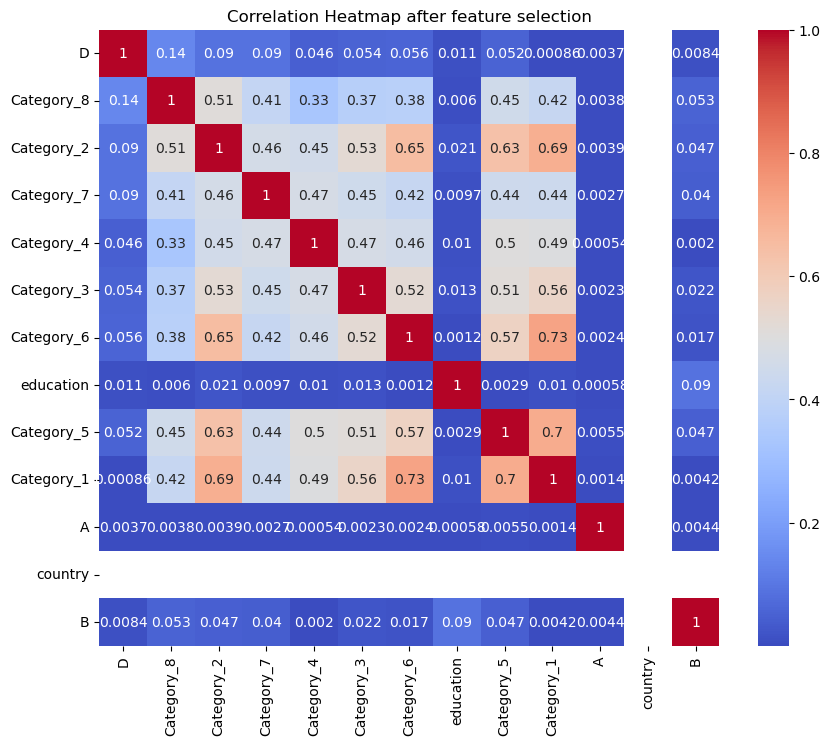

In [101]:
# check the correlation between features:
corr_matrix = abs(X_selected.corr())

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,              
            cmap='coolwarm',         
            xticklabels=corr_matrix.columns,
            yticklabels=corr_matrix.columns)

plt.title('Correlation Heatmap after feature selection')
plt.show()

After feature selection, Category 1 and and 5, and 1 & 6 are correlated.

Text(0.5, 1, 'Pair Plot of Selected Features')

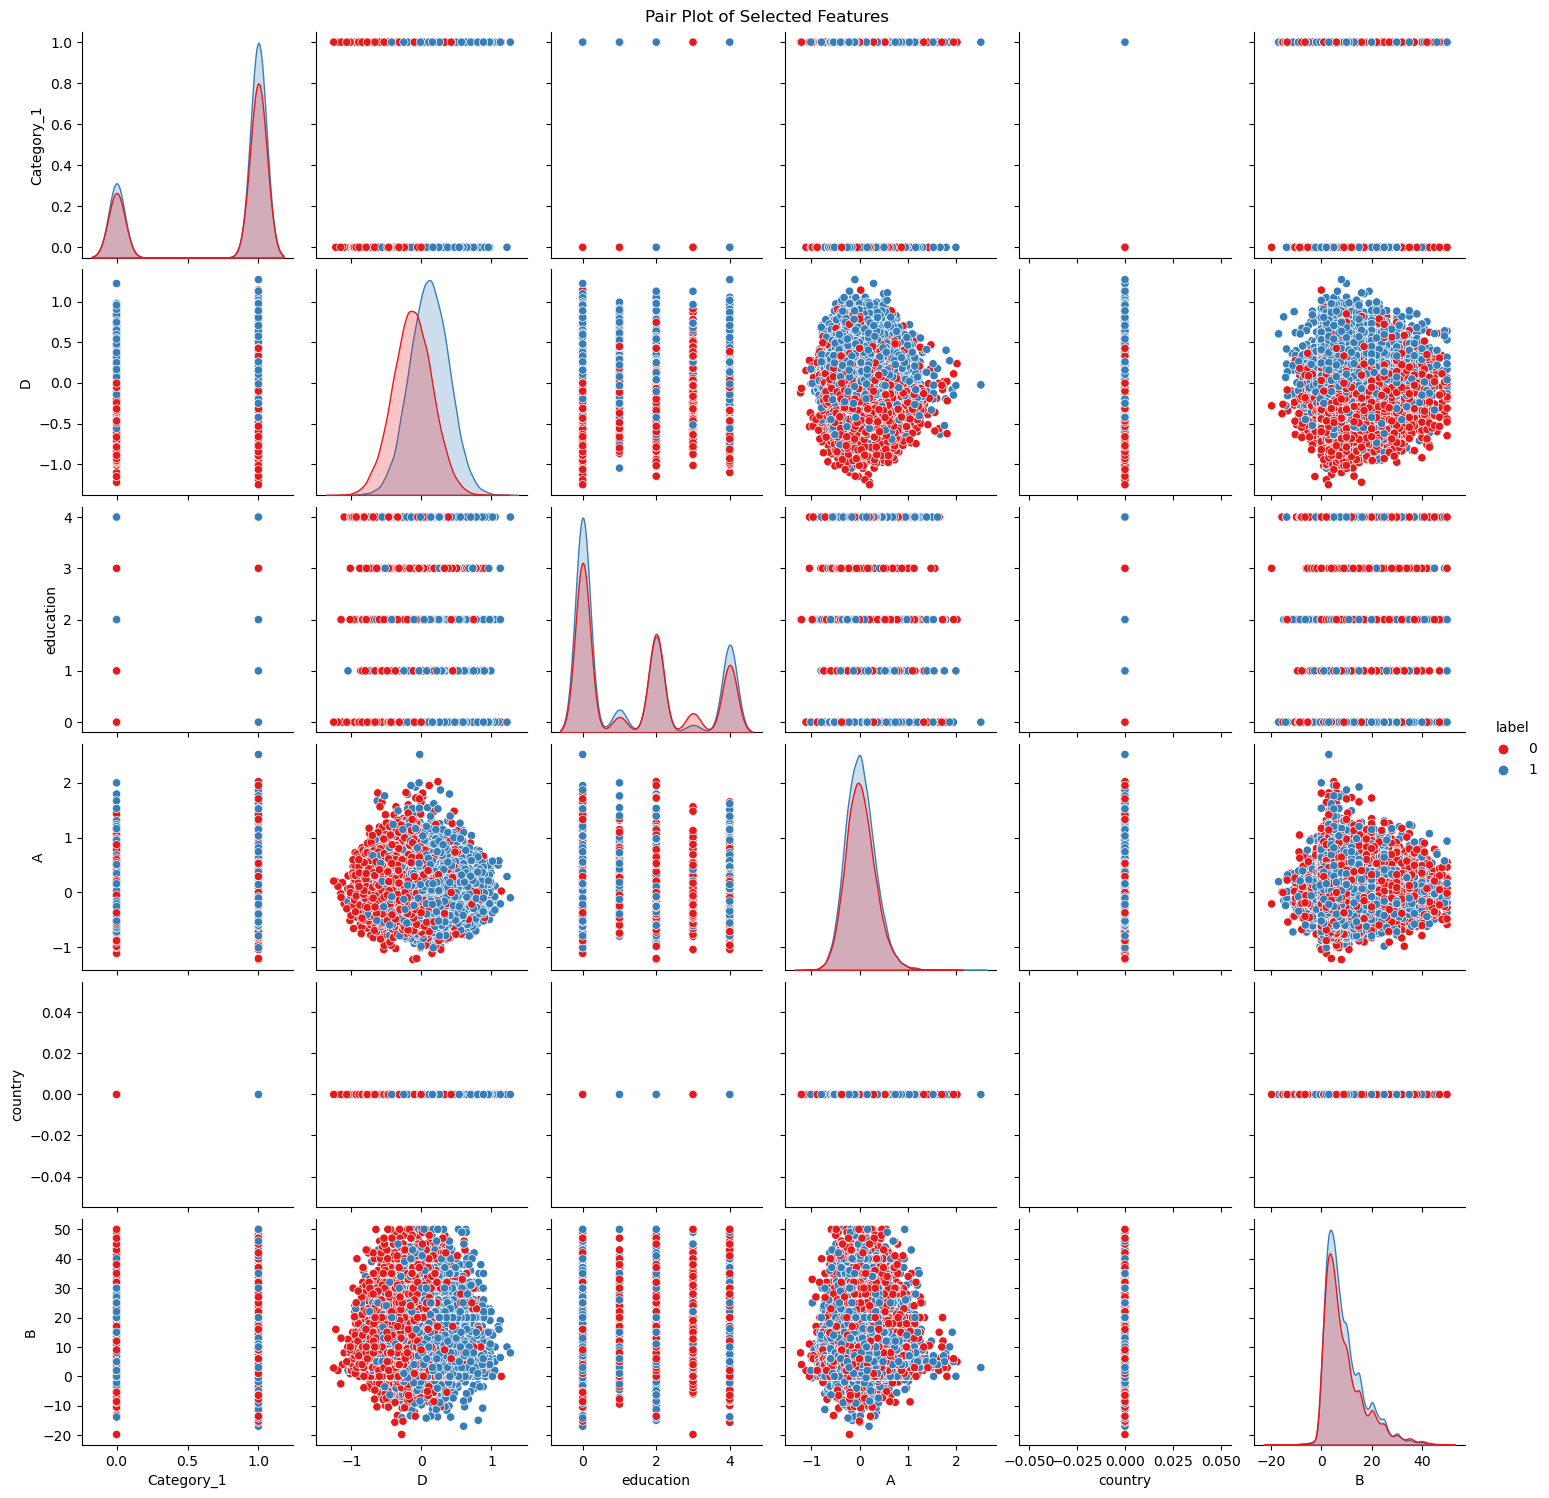

In [102]:
# visualize pair plot
numerical_features = ['Category_1', 'D','label',	'education',	'is_dev'	,'A'	,'country'	,'B',	'worked_in_the_past']
x_ = train_df_norm.iloc[:, selected_indices]
custom_palette = sns.color_palette("Set1", len(x_['label'].unique()))
pair_plot = sns.pairplot(x_[numerical_features], hue='label', palette=custom_palette)
plt.suptitle('Pair Plot of Selected Features', y=1)

It can be seen from the pair plot, the combination between feature A and D can seperate between the two labels, as the red and the blue dots are relativley seperated and not random. and for example the combination of country and D gives a good separtion as well, and more others.
On the diagonal, each feature with itself dont give good separtion, but a combination of all features together give better separation .

In [103]:
train_df_norm

,worked_in_the_past,age_group,disability,is_dev,education,sex,mental_issues,years_of_experience,A,B,...,prev_salary,label,Category_1,Category_2,Category_3,Category_4,Category_5,Category_6,Category_7,Category_8
0,1.0,1.0,0.0,0.0,4.0,1.0,0.0,0.03125,-0.228548,1.0,...,0.052952,1,1,1,1,1,1,0,0,1
1,1.0,1.0,0.0,1.0,4.0,1.0,1.0,-0.15625,0.088332,7.0,...,0.265237,0,1,0,1,1,1,0,0,0
2,1.0,0.0,0.0,0.0,4.0,1.0,1.0,0.40625,-0.091845,15.0,...,0.071089,0,1,1,0,0,1,1,0,0
3,1.0,1.0,0,0.0,4.0,1.0,0.0,-0.06250,0.687415,7.0,...,-0.110808,0,1,1,0,1,0,1,1,1
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.00000,-0.596245,4.0,...,0.268425,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55457,1.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.15625,0.157349,2.0,...,0.133718,1,0,0,0,0,0,0,0,0
55458,1.0,0.0,0,0.0,2.0,1.0,0.0,0.31250,-0.077161,20.0,...,0.569411,1,1,1,1,1,1,1,1,1
55459,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.71875,-0.104169,35.0,...,0.257030,1,1,1,1,1,1,1,1,1
55460,1.0,1.0,0,0.0,0.0,1.0,0.0,-0.18750,-0.218380,3.0,...,0.290289,1,1,1,1,0,1,1,0,1


# Process test set

In [104]:

test_df_numeric,category_mappings_test = convert_categorical_to_numeric(test_df)
#print('category mapping:',category_mappings_test)
test_df_cleaned1 = handling_missing_values_new(test_df_numeric)
test_df_cleaned = categorize_and_encode_countries(test_df_cleaned1)
test_df_cleaned = categorize_and_encode_techs(test_df_cleaned)
test_df_cleaned = test_df_cleaned.drop('ID', axis=1)
#normalize:
test_df_cleaned[['years_of_experience','A','D','prev_salary']] = (test_df_cleaned[['years_of_experience','A','D','prev_salary']] - median_train) / IQR_train
#select features
X_test_selected = test_df_cleaned.iloc[:, selected_indices]

X_test_selected


,D,Category_8,Category_2,Category_7,Category_4,Category_3,Category_6,education,is_dev,Category_5,Category_1,A,country,B,worked_in_the_past
0,-0.274409,0,1,0,0,1,1,0.0,0.0,0,1,0.296110,3.0,3.000000,0.0
1,-0.143510,0,1,0,1,0,1,4.0,1.0,0,1,-0.295882,0.0,3.956655,1.0
3,0.485408,1,1,1,1,1,1,0.0,0.0,1,1,-0.352230,0.0,8.248926,1.0
4,0.048721,0,1,0,0,1,1,4.0,0.0,0,1,-0.431371,2.0,34.000000,0.0
5,0.406743,0,0,0,1,0,1,4.0,0,1,1,-0.234986,0.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,0.006591,0,0,0,0,0,0,1.0,0.0,0,0,-0.309178,3.0,32.000000,1.0
17996,0.032229,0,0,0,1,0,0,2.0,0.0,1,1,0.233137,2.0,3.000000,1.0
17997,-0.375355,0,0,1,1,1,1,4.0,0.0,1,1,0.454679,2.0,11.000000,1.0
17998,0.030709,0,1,0,0,0,1,2.0,0.0,1,1,-0.198732,2.0,5.000000,0


In [105]:
test_df_cleaned.isna().sum() # verified 

worked_in_the_past     0
age_group              0
disability             0
is_dev                 0
education              0
sex                    0
mental_issues          0
years_of_experience    0
A                      0
B                      0
C                      0
D                      0
country                0
prev_salary            0
Category_1             0
Category_2             0
Category_3             0
Category_4             0
Category_5             0
Category_6             0
Category_7             0
Category_8             0
dtype: int64

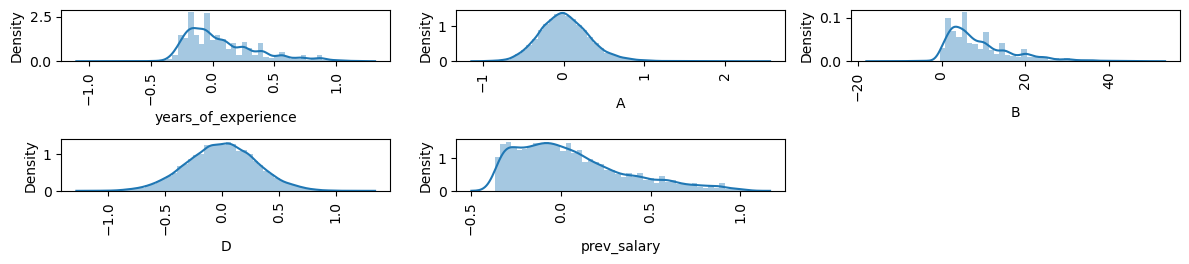

In [106]:
#get the data that is not binary

plt.figure(figsize=(12,6))
for i,col in enumerate(non_binary_columns,1):
    plt.subplot(5,3,i)
    sns.distplot(test_df_cleaned[col])
    plt.xlabel(col)
    plt.tight_layout()  
    plt.xticks(rotation=90)

The test is normalized, same as explained in the train

## Build Models 

Chosen models: 

K-Nearest Neighbors (KNN)


LogisticRegression

Random Forest


Adaptive Boosting (AdaBoost)

Explaination on the hyperparameters can be found in the report.

Train the models

In [107]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

def train_models_with_cv(X, y, model, cv=5):
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(y, pd.Series):
        y = y.values
    
    # StratifiedKFold object - cross validation
    skf = StratifiedKFold(n_splits=cv)
    
    
    tprs_val = []
    tprs_train = []
    aucs_val = []
    aucs_train = []
    mean_fpr = np.linspace(0, 1, 100)
    
    plt.figure(figsize=(10, 8))
    best_auc = 0
    best_model = None

    for i, (train_index, validation_index) in enumerate(skf.split(X, y)):
        X_train, X_validation = X[train_index], X[validation_index]
        y_train, y_validation = y[train_index], y[validation_index]
        scaler = StandardScaler() # scaling
       
        X_train_scaled = scaler.fit_transform(X_train)
        X_validation_scaled = scaler.transform(X_validation)
        
        model.fit(X_train_scaled, y_train)
        
        # Predict the probabilities for validation and training sets
        y_prob_val = model.predict_proba(X_validation_scaled)[:, 1]
        y_prob_train = model.predict_proba(X_train_scaled)[:, 1]
        
        fpr_val, tpr_val, _ = roc_curve(y_validation, y_prob_val)
        roc_auc_val = auc(fpr_val, tpr_val)
        aucs_val.append(roc_auc_val)
        
        # AUC and ROC graphs for training set
        fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
        roc_auc_train = auc(fpr_train, tpr_train)
        aucs_train.append(roc_auc_train)
        
        tprs_val_interp = np.interp(mean_fpr, fpr_val, tpr_val)
        tprs_val_interp[0] = 0.0
        tprs_val.append(tprs_val_interp)
        
        tprs_train_interp = np.interp(mean_fpr, fpr_train, tpr_train)
        tprs_train_interp[0] = 0.0
        tprs_train.append(tprs_train_interp)
        
        # Plot ROC for each fold
        plt.plot(fpr_val, tpr_val, lw=1, alpha=0.3, label=f'Validation ROC Fold {i+1} (AUC = {roc_auc_val:.2f})')
        plt.plot(fpr_train, tpr_train, lw=1, alpha=0.3, linestyle='--', label=f'Train ROC Fold {i+1} (AUC = {roc_auc_train:.2f})')
        
        # Save the best model (based on validation AUC)
        if roc_auc_val > best_auc:
            best_auc = roc_auc_val
            best_model = model

    #Compute ROC and AUC for validation set
    # Calculate mean and standard deviation of ROC for validation and training
    mean_tpr_val = np.mean(tprs_val, axis=0)
    mean_tpr_val[-1] = 1.0
    mean_auc_val = auc(mean_fpr, mean_tpr_val)
    std_auc_val = np.std(aucs_val)

    mean_tpr_train = np.mean(tprs_train, axis=0)
    mean_tpr_train[-1] = 1.0
    mean_auc_train = auc(mean_fpr, mean_tpr_train)
    std_auc_train = np.std(aucs_train)
    
    # Plot mean ROC for validation and training
    plt.plot(mean_fpr, mean_tpr_val, color='b', label=r'Mean Validation ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_val, std_auc_val), lw=2, alpha=0.8)
    plt.plot(mean_fpr, mean_tpr_train, color='r', linestyle='--', label=r'Mean Train ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_train, std_auc_train), lw=2, alpha=0.8)
    
    # plot standard deviation in ROC
    std_tpr_val = np.std(tprs_val, axis=0)
    tprs_val_upper = np.minimum(mean_tpr_val + std_tpr_val, 1)
    tprs_val_lower = np.maximum(mean_tpr_val - std_tpr_val, 0)
    plt.fill_between(mean_fpr, tprs_val_lower, tprs_val_upper, color='grey', alpha=0.2, label=r'$\pm$ 1 std. dev. (Validation)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve with Cross-Validation (Train vs Validation)')
    plt.legend(loc='lower right')
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_validation, model.predict(X_validation_scaled))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix (validation Data)')
    plt.show()
    return best_model    # Return the best model


def evaluate_model(model, X_test,test_df):
    # Scale the test data
    scaler = StandardScaler()
    X_test_scaled = scaler.fit_transform(X_test)
    
    # Predict class labels for the test data
    y_prob_test = model.predict_proba(X_test_scaled)[:,1]
    
    results_df = pd.DataFrame({'ID':test_df['ID'],'predict_proba': y_prob_test})
    results_df.to_csv('results_55.csv', index=False)
    return y_prob_test


X = X_selected
y = train_df_cleaned['label']

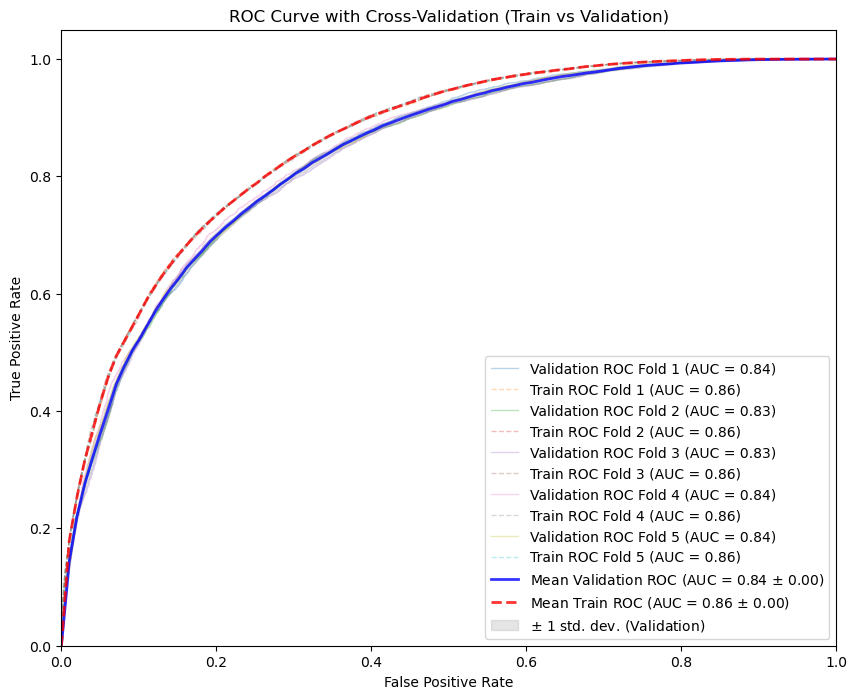

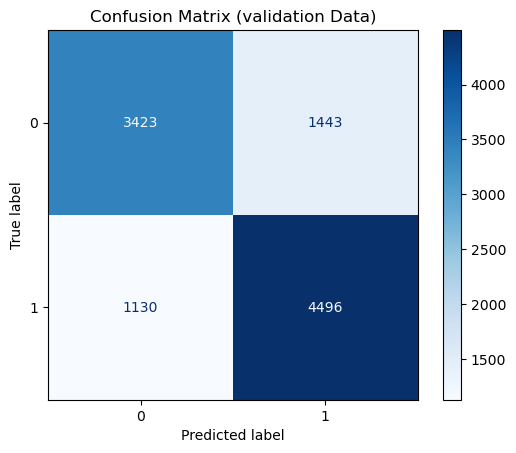

In [108]:
model_random_forest = RandomForestClassifier(
    n_estimators=200,        # מספר העצים ביער
    max_depth=10,            # העומק המקסימלי של כל עץ
    min_samples_split=5,     # מספר הדוגמאות המינימלי הנדרש לפיצול צומת
    min_samples_leaf=4,      # מספר הדוגמאות המינימלי הנדרש בכל עלה
    max_features='sqrt',     # מספר המאפיינים שנבחרים לפיצול צומת
    bootstrap=True,          # שימוש בטכניקת Bootstrap
    criterion='gini',        # הקריטריון המשמש למדידת איכות הפיצולים
    random_state=42,         # זרע לאתחול הדגימות האקראיות
    max_samples=None         # שימוש בכל הדגימות הזמינות אם bootstrap=True
) 
best_model_random_froset = train_models_with_cv(X, y, model=model_random_forest, cv=5)


The confusion matrix from the Random Forest model on the validation data provides insight into the model's classification performance:

True Negatives (3423): The model correctly predicted the negative class (0), meaning it correctly identified 3423 instances as negative.

False Positives (1443): The model incorrectly predicted the positive class (1) when the true class was negative. These are Type I errors, where 1443 instances were falsely labeled as positive.

False Negatives (1130): The model incorrectly predicted the negative class (0) when the true class was positive. These are Type II errors, where 1130 instances were falsely labeled as negative.

True Positives (4496): The model correctly predicted the positive class (1), meaning it correctly identified 4496 instances as positive.

In summary, the model performs well in correctly identifying both positive and negative instances, as indicated by the relatively high numbers in the true positive and true negative cells. However, there are still some errors, as shown by the non-zero false positives and false negatives, which highlight areas where the model could be improved.


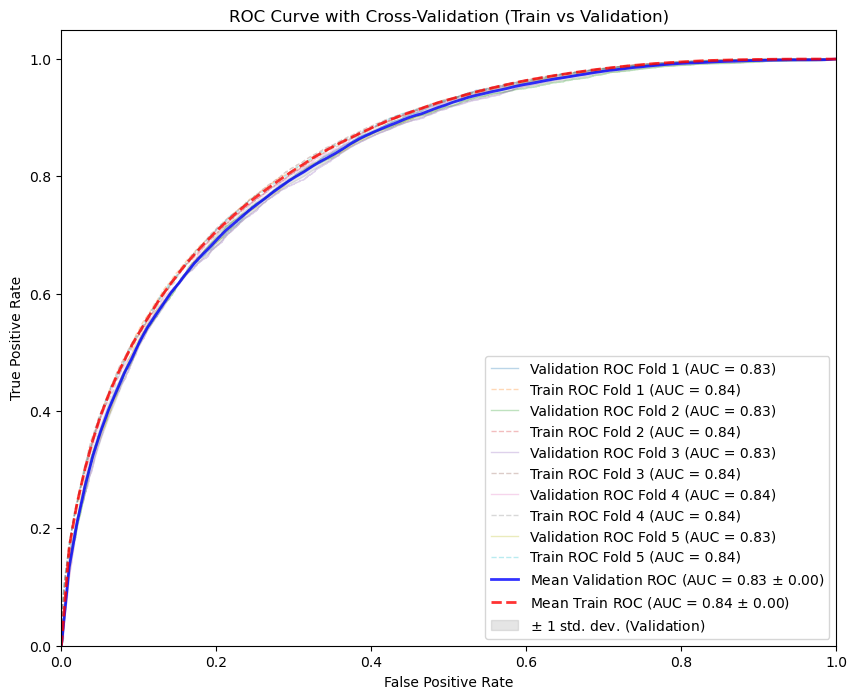

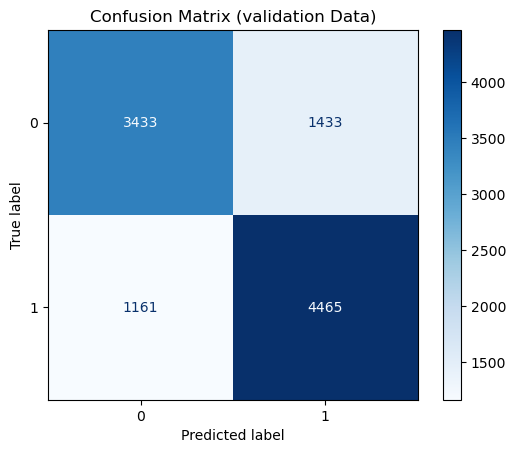

In [109]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model_AdaBoost = AdaBoostClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=2),  
    n_estimators=100,           # מספר המודלים החלשים
    learning_rate=0.5,          # קצב הלמידה
    algorithm='SAMME.R',        # אלגוריתם SAMME.R
    random_state=42             # זרע לאתחול אקראי
)
best_model_model_AdaBoost = train_models_with_cv(X, y, model=model_AdaBoost, cv=5)

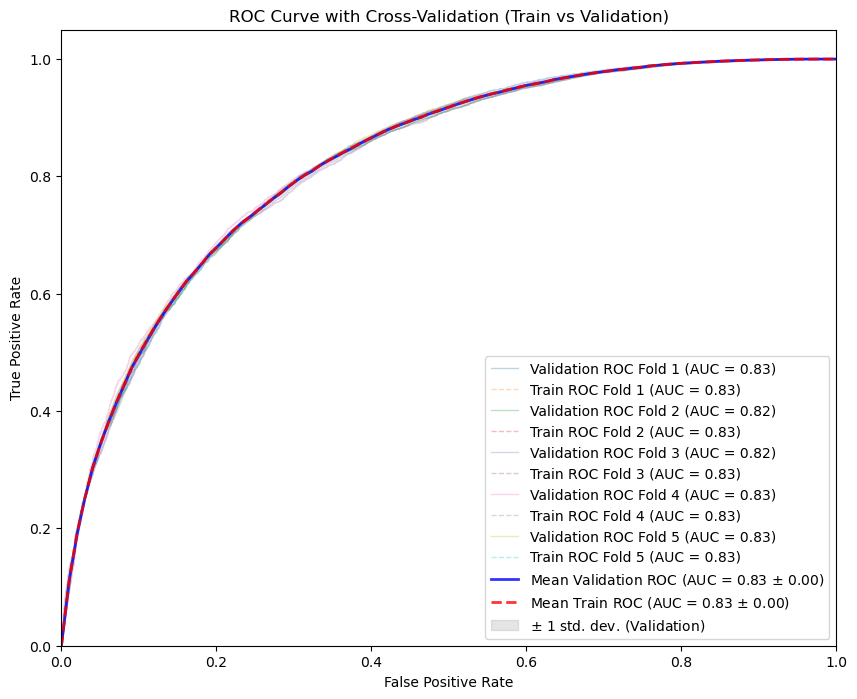

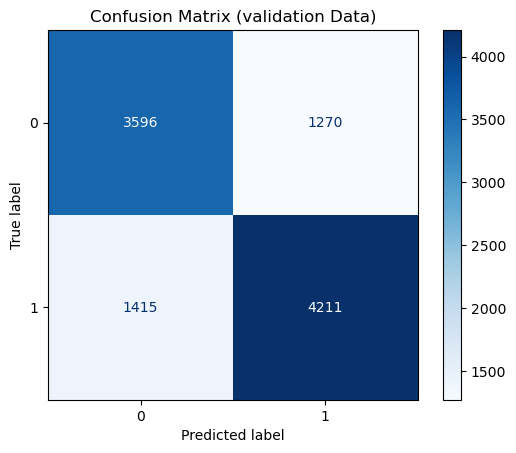

In [110]:
from sklearn.linear_model import LogisticRegression


model_LR = LogisticRegression(
    penalty='l2',             # עונש L2 רגיל
    C=0.1,                    # קבוע עונש נמוך יותר
    solver='saga',            # אלגוריתם SAGA שמתאים לעונש L2 ולנתונים גדולים
    max_iter=200,             # מספר איטרציות מרבי
    multi_class='multinomial',# התמודדות עם בעיות רב-קטגוריות
    fit_intercept=True,       # הכללת חותך (intercept) במודל
    random_state=42,          # זרע לאתחול אקראי
    class_weight='balanced'   # משקל מאוזן לכיתות שונות
)

best_model_LR = train_models_with_cv(X, y, model=model_LR, cv=5)

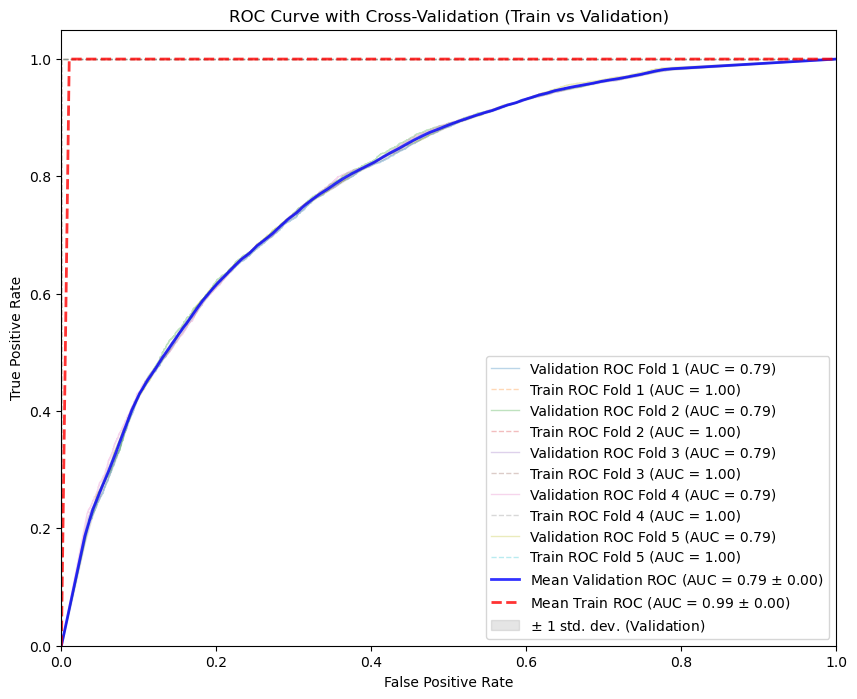

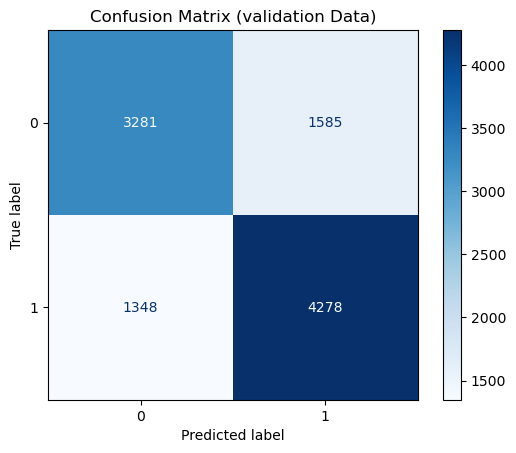

In [111]:

from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(
    n_neighbors=7,            # מספר השכנים הקרובים
    weights='distance',       # המשקלות לפי המרחק
    algorithm='auto',         # בחירת אלגוריתם אוטומטית
    leaf_size=30,             # גודל עלה ב-Ball Tree או KD Tree
    p=2,                      # שימוש במרחק אוקלידי (p=2)
    metric='minkowski',       # מטריקת Minkowski (ברירת המחדל)
    n_jobs=-1                 # שימוש בכל המעבדים הזמינים לחישוב
)


best_model_knn = train_models_with_cv(X, y, model=model_knn, cv=5)

This initial KNeighborsClassifier model was set up with custom hyperparameters, such as using 7 neighbors, weighted distances, and automatic algorithm selection. However, the model suffered from overfitting, as seen in the ROC curves where the training performance was significantly higher than the validation performance. To address this, we increased the number of neighbors to 150. This adjustment give a better balance between the training and validation performance, as the ROC curves now show more consistent AUC scores between the two sets, indicating reduced overfitting and a more generalized model.

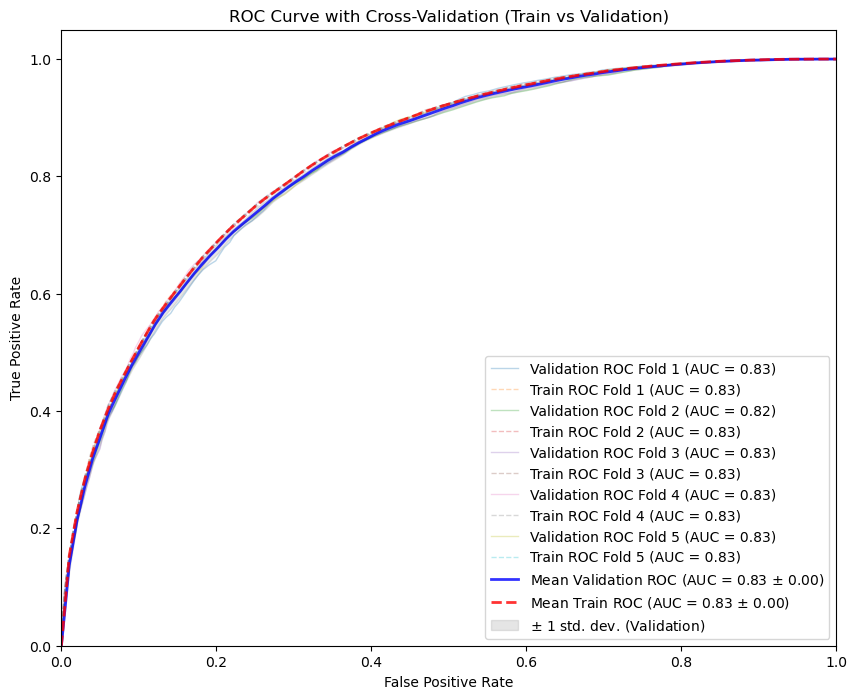

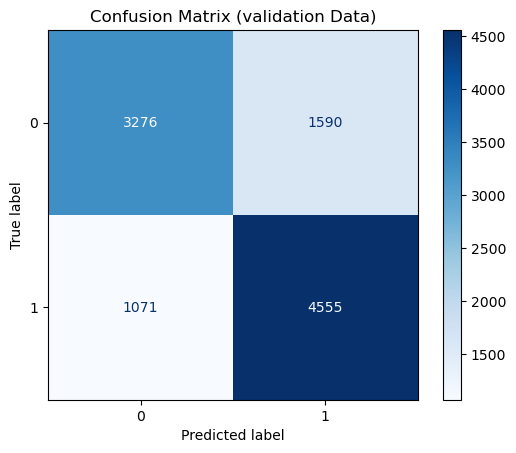

In [112]:
model_knn = KNeighborsClassifier(n_neighbors=150)

best_model_knn = train_models_with_cv(X, y, model=model_knn, cv=5)

The lack of overfitting in other models: KNN, LogesticRegression, AdaBoost, suggests they are well-suited for your data, providing a good trade-off between learning the data and generalizing to new examples. 

 # Save results for the chosen best model 

In [113]:
best_model = best_model_random_froset
X_test = X_test_selected

y_pred_test_adaboost = evaluate_model(best_model, X_test,test_df_cleaned1)


# Feature importance graph


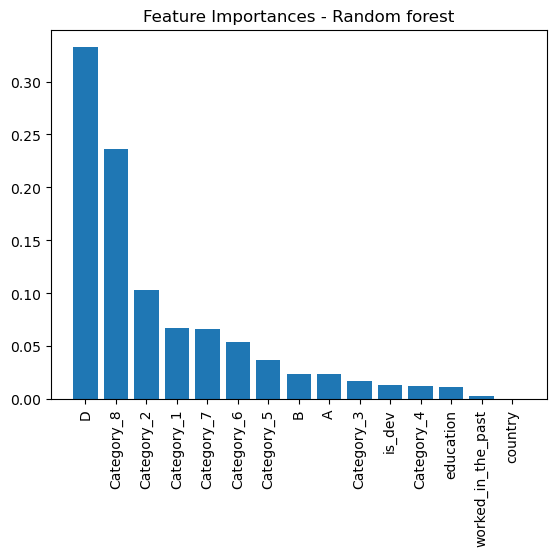

In [114]:
import matplotlib.pyplot as plt
y_train = train_df_cleaned['label']
rf_clf = best_model
rf_clf.fit(X_selected, y_train)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

# גרף חשובויות הפיצ'רים
plt.figure()
plt.title("Feature Importances - Random forest")
plt.bar(range(X_selected.shape[1]), importances[indices], align="center")
plt.xticks(range(X_selected.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.show()

Analysis of Feature Importance:

The feature importance graph, generated using the Random Forest model, show the significance of features in predicting whether candidates are accepted for a job or not.

- *D:* This feature stands out as the most significant, with the highest importance score. If we assume that "D" represents the height of a person, its prominence in determining job acceptance is surprising. Height is generally not a relevant factor for most jobs, unless the role specifically requires certain physical attributes. The high importance of this feature could indicate that it is either correlated with another significant factor or it could suggest the presence of bias within the model.

- *Category 8:* This feature is the second most important. The Category 8 represents "other technologies" in our code," its high ranking is understandable as these skills are often crucial in job roles.

- *The rest categories: * These are also explainable and understandable since htese are experiences and skills that is relevant to job acceptance.
reminder: the categories are:
'programming_languages': 1,
        'frameworks_and_libraries': 2,
        'Cloud Providers': 3,
        'Containerization/Orchestration': 4,
        'devops_and_infrastructure': 5,
        'SQL Databases': 6,
        'NoSQL Databases': 7,
        'other_technologies': 8

- *Is_dev:* If this feature indicates whether a candidate is a developer or not, its lower importance might imply that while being a developer is relevant, other factors like specific skills or experience (captured in other categories) play a more critical role in the decision-making process.

- *Category 3:* This feature, having lower importance, could represent secondary qualifications or soft skills that, while beneficial, are not decisive in the acceptance process.

- *Education, A, Worked_in_the_past:* These features are among the least important. For example:
  - *Education:* While educational background is typically important, its low importance here might suggest that the model prioritizes experience and skills over formal education.
  - *A:* This feature might represent a less critical skill or factor.
  - *Worked_in_the_past:* This could represent whether the candidate has previous work experience. Its low importance may suggest that the model focuses more on the quality of experience (as captured by other features) rather than the mere fact of having worked before.


pipeline (לשחזור מהיר)

category mapping: {'worked_in_the_past': {0: 'F', 1: 'T'}, 'age_group': {0: 'old', 1: 'young'}, 'disability': {0: 'No', 1: 'Yes'}, 'is_dev': {0: 'developer', 1: 'non-developer'}, 'education': {0: 'BA/BSc', 1: 'High school', 2: 'MA/MSc', 3: 'Phd', 4: 'other'}, 'sex': {0: 'Female', 1: 'Male', 2: 'Other'}, 'mental_issues': {0: 'No', 1: 'Yes'}, 'C': {0: 'aa', 1: 'br', 2: 'ca', 3: 'hr', 4: 'mn', 5: 'rhz', 6: 'ww'}}
category mapping: {'worked_in_the_past': {0: 'F', 1: 'T'}, 'age_group': {0: 'old', 1: 'young'}, 'disability': {0: 'No', 1: 'Yes'}, 'is_dev': {0: 'developer', 1: 'non-developer'}, 'education': {0: 'BA/BSc', 1: 'High school', 2: 'MA/MSc', 3: 'Phd', 4: 'other'}, 'sex': {0: 'Female', 1: 'Male', 2: 'Other'}, 'mental_issues': {0: 'No', 1: 'Yes'}, 'C': {0: 'aa', 1: 'br', 2: 'ca', 3: 'hr', 4: 'mn', 5: 'rhz', 6: 'ww'}}


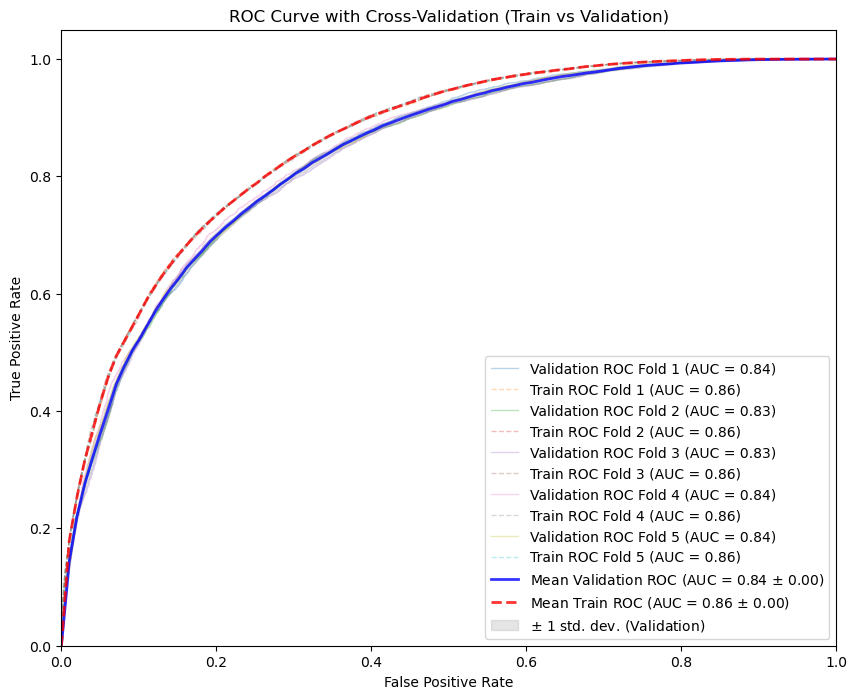

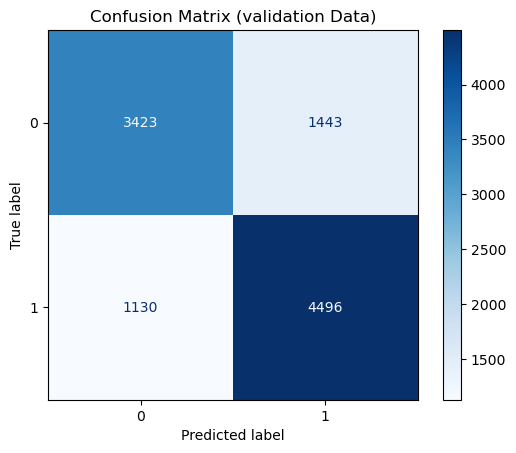

In [115]:
#remove_outliers(train_df, column, lower_quantile=0.05, upper_quantile=0.95, threshold=1.5)

train_df_numeric,category_mappings = convert_categorical_to_numeric(train_df)
print('category mapping:',category_mappings)
train_df_cleaned = handling_missing_values_new(train_df_numeric)
train_df_cleaned = categorize_and_encode_countries(train_df_cleaned)
train_df_cleaned = categorize_and_encode_techs(train_df_cleaned)
# clean the ID column since we don't think it contribute to the prediction
train_df_cleaned = train_df_cleaned.drop('ID', axis=1)
train_df_norm,median_train,IQR_train = normalize_data(train_df_cleaned, ['years_of_experience','A','D','prev_salary']) 
X_selected = train_df_norm.drop(columns=['label']).iloc[:, selected_indices]


test_df_numeric,category_mappings_test = convert_categorical_to_numeric(test_df)
print('category mapping:',category_mappings_test)
test_df_cleaned1 = handling_missing_values_new(test_df_numeric)
test_df_cleaned = categorize_and_encode_countries(test_df_cleaned1)
test_df_cleaned = categorize_and_encode_techs(test_df_cleaned)
test_df_cleaned = test_df_cleaned.drop('ID', axis=1)
#normalize:
test_df_cleaned[['years_of_experience','A','D','prev_salary']] = (test_df_cleaned[['years_of_experience','A','D','prev_salary']] - median_train) / IQR_train
#select features
X_test_selected = test_df_cleaned.iloc[:, selected_indices]

model_random_forest = RandomForestClassifier(
    n_estimators=200,        # מספר העצים ביער
    max_depth=10,            # העומק המקסימלי של כל עץ
    min_samples_split=5,     # מספר הדוגמאות המינימלי הנדרש לפיצול צומת
    min_samples_leaf=4,      # מספר הדוגמאות המינימלי הנדרש בכל עלה
    max_features='sqrt',     # מספר המאפיינים שנבחרים לפיצול צומת
    bootstrap=True,          # שימוש בטכניקת Bootstrap
    criterion='gini',        # הקריטריון המשמש למדידת איכות הפיצולים
    random_state=42,         # זרע לאתחול הדגימות האקראיות
    max_samples=None         # שימוש בכל הדגימות הזמינות אם bootstrap=True
) 
best_model_random_froset = train_models_with_cv(X, y, model=model_random_forest, cv=5)

best_model = best_model_random_froset
y_pred_test_adaboost = evaluate_model(best_model, X_test_selected,test_df_cleaned1)
